In [9]:
import numpy as np
import pandas as pd

In [10]:
df = pd.read_csv("../../data/district_agreement_for_gee.csv")
filtered_df = df[df["agreement_Rice"] >= 0.8]

In [11]:
df.columns

Index(['State', 'District', 'agreement', 'agreement_Peas', 'census_Peas_ha',
       'pred_Peas_ha', 'agreement_Maize', 'census_Maize_ha', 'pred_Maize_ha',
       'agreement_Rice', 'census_Rice_ha', 'pred_Rice_ha', 'agreement_Cotton',
       'census_Cotton_ha', 'pred_Cotton_ha', 'agreement_Sugarcane',
       'census_Sugarcane_ha', 'pred_Sugarcane_ha', 'census_total_ha',
       'pred_total_ha'],
      dtype='object')

In [29]:
df.loc[df["State"] == "Andhra Pradesh"]['agreement_Rice'].mean(), df.loc[df["State"] == "Assam"]['agreement_Rice'].std()

(0.8298076923076925, 0.0646690894969431)

In [ ]:
df.loc[df["State"] == "Assam"]['agreement_Rice'].mean(), df.loc[df["State"] == "Assam"]['agreement_Rice'].std()

(0.9304636363636363, 0.0646690894969431)

In [28]:
df.loc[df["State"] == "Maharashtra"]['agreement_Rice'].mean(), df.loc[df["State"] == "Assam"]['agreement_Rice'].std()

(0.4225441176470588, 0.0646690894969431)

In [30]:
df.loc[df["State"] == "Tripura"]['agreement_Rice'].mean(), df.loc[df["State"] == "Assam"]['agreement_Rice'].std()

(0.9651000000000001, 0.0646690894969431)

In [13]:
orig_count = df.shape[0]
filtered_count = filtered_df.shape[0]
print(f"Original count: {orig_count}, Filtered count: {filtered_count}, Percentage filtered: {filtered_count/orig_count:.2%}")

Original count: 731, Filtered count: 494, Percentage filtered: 67.58%


## Per-district Pearson correlation — Peak GCVI vs Rice Yield

State-level pooled Pearson r between peak GCVI and Kharif rice yield, across all districts and years (2013–2024), for **30 Indian states**.

---

### ⚠ Data limitations — read before interpreting

The analysis cell prints this same summary on every run via `print_data_limitations()`.

**4 states excluded entirely**

| State | Reason |
|---|---|
| Sikkim | GAUL has the old 4 districts (East/North/South/West); yield uses the post-2021 six. **100%** of yield rows unmatchable. |
| Arunachal Pradesh | GAUL boundaries predate district splits — **65%** of yield rows unmatchable. |
| Delhi | No Kharif Rice records in the DES yield data. |
| Lakshadweep | No Kharif Rice records in the DES yield data. |

**5 states included with partial coverage** — GAUL boundaries predate recent district splits, so some yield rows drop at the merge:

| State | Yield rows lost | Note |
|---|---|---|
| Andhra Pradesh | **38%** | The 2022 reorganisation created 13 districts absent from GAUL. Results reflect roughly the **pre-2022 district set** — treat `n` accordingly. |
| Mizoram | 14% | Recent district splits. |
| Madhya Pradesh | 12% | Maihar, Mauganj, Pandhurna absent from GAUL. |
| Nagaland | 11% | Recent district splits. |
| Chhattisgarh | 11% | Recent district splits. |

The correlation cell prints a **low-coverage warning** for any state below 90% match, so a low `r` driven by missing districts is never mistaken for a genuinely weak GCVI–yield relationship.

**Other caveats**

- **Himachal Pradesh**: GAUL stores a corrupted district name — `"Ham|Rpur"`, with a pipe character instead of `i`. Handled in `NAME_FIXES`, but it is a defect in the source data.
- **Dadra & Nagar Haveli** has no row in `district_agreement_for_gee.csv`, so its agreement columns are `NaN` and it drops out of the agreement scatter plots.
- **Jammu & Kashmir** has yield data but no GAUL 2024 boundary, so no GCVI TIFs exist for it.
- Punjab and MP use the `crop` mask filename; every other state uses `jordi`. These are the **same product** — `MASK_LABELS` maps both to "Crop mask" and the heatmap merges them into one column.
- 14 newly-added states are still `'unclassified'` in `LANDCOVER_CLASS` and plot in grey until you assign them.

In [3]:
import glob, re, os, tempfile
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('../../outputs', exist_ok=True)

BDY = '../../data/district_boundaries'

# ═══════════════════════════════════════════════════════════════════════════
# DATA LIMITATIONS — printed by print_data_limitations() in the analysis cell
# ═══════════════════════════════════════════════════════════════════════════
# 'shp' : GAUL district boundary GeoJSON
# 'state_name' : spelling used in the DES yield CSVs (differs from GAUL!)
#
# EXCLUDED from REGIONS entirely (see DATA_LIMITATIONS below for why):
#   sikkim, arunachal_pradesh  — GAUL boundaries predate redistricting
#   delhi, lakshadweep         — no Kharif Rice yield records at all

DATA_LIMITATIONS = {
    'excluded': {
        'sikkim': 'GAUL has the old 4 districts (East/North/South/West); yield uses the '
                  'post-2021 six (Gangtok, Gyalshing, Mangan, Namchi, Pakyong, Soreng). '
                  '100% of yield rows unmatchable.',
        'arunachal_pradesh': 'GAUL boundaries predate district splits — 65% of yield rows '
                             'unmatchable.',
        'delhi':       'No Kharif Rice records in the DES yield data.',
        'lakshadweep': 'No Kharif Rice records in the DES yield data.',
    },
    # states included, but with a known share of yield rows dropped at the merge
    'partial_coverage': {
        'andhra_pradesh': (38, 'The 2022 reorganisation created 13 districts absent from GAUL. '
                               'Results reflect roughly the pre-2022 district set.'),
        'mizoram':      (14, 'Recent district splits absent from GAUL.'),
        'mp':           (12, 'Maihar, Mauganj, Pandhurna absent from GAUL.'),
        'nagaland':     (11, 'Recent district splits absent from GAUL.'),
        'chhattisgarh': (11, 'Recent district splits absent from GAUL.'),
    },
    # raw + ESRI work, but the jordi crop map has ZERO pixels here, so no
    # crop-mask delta can be computed (verified against the 2020 TIFs)
    'no_crop_mask': ['goa', 'andaman_nicobar', 'dadra_nagar_haveli'],
    'other': [
        'Himachal Pradesh: GAUL stores a corrupted district name ("Ham|Rpur" — pipe '
        'character instead of "i"). Handled in NAME_FIXES, but it is a source-data defect.',
        'dadra_nagar_haveli has no row in district_agreement_for_gee.csv, so its '
        'agreement columns are NaN and it drops out of the agreement scatter plots.',
        'Jammu & Kashmir has yield data but no GAUL 2024 boundary — no TIFs exist for it.',
        'Punjab and MP use the "crop" mask name; every other state uses "jordi". '
        'They are the same product (see MASK_LABELS).',
        'Chandigarh is a single district (n_districts=1), so its r is a 12-point '
        'time series, not a pooled cross-section. Treat it as anecdotal.',
    ],
}

def print_data_limitations():
    """Reminder banner — call at the top of any analysis run."""
    L = DATA_LIMITATIONS
    print('=' * 78)
    print('DATA LIMITATIONS — read before interpreting these results')
    print('=' * 78)
    print(f"\nEXCLUDED STATES ({len(L['excluded'])}):")
    for k, why in L['excluded'].items():
        print(f"  • {k}: {why}")
    print(f"\nPARTIAL COVERAGE — included, but yield rows dropped at merge:")
    for k, (pct, why) in sorted(L['partial_coverage'].items(), key=lambda x: -x[1][0]):
        print(f"  • {k}: ~{pct}% of yield rows lost. {why}")
    print(f"\nNO CROP MASK — jordi crop map has zero pixels; raw & ESRI only:")
    print(f"  • {', '.join(L['no_crop_mask'])}")
    print(f"\nOTHER:")
    for note in L['other']:
        print(f"  • {note}")
    print('=' * 78 + '\n')


REGIONS = {
    'punjab':             {'shp': f'{BDY}/Punjab_Districts_GAUL.geojson',             'state_name': 'Punjab'},
    'mp':                 {'shp': f'{BDY}/Madhya_Pradesh_Districts_GAUL.geojson',     'state_name': 'Madhya Pradesh'},
    'up':                 {'shp': f'{BDY}/UP_Districts_GAUL.geojson',                 'state_name': 'Uttar Pradesh'},
    'wb':                 {'shp': f'{BDY}/WB_Districts_GAUL.geojson',                 'state_name': 'West Bengal'},
    'telangana':          {'shp': f'{BDY}/Telangana_Districts_GAUL.geojson',          'state_name': 'Telangana'},
    'maharashtra':        {'shp': f'{BDY}/Maharashtra_Districts_GAUL.geojson',        'state_name': 'Maharashtra'},
    'karnataka':          {'shp': f'{BDY}/Karnataka_Districts_GAUL.geojson',          'state_name': 'Karnataka'},
    'andhra_pradesh':     {'shp': f'{BDY}/Andhra_Pradesh_Districts_GAUL.geojson',     'state_name': 'Andhra Pradesh'},
    'tamil_nadu':         {'shp': f'{BDY}/Tamil_Nadu_Districts_GAUL.geojson',         'state_name': 'Tamil Nadu'},
    'odisha':             {'shp': f'{BDY}/Odisha_Districts_GAUL.geojson',             'state_name': 'Odisha'},
    'jharkhand':          {'shp': f'{BDY}/Jharkhand_Districts_GAUL.geojson',          'state_name': 'Jharkhand'},
    'assam':              {'shp': f'{BDY}/Assam_Districts_GAUL.geojson',              'state_name': 'Assam'},
    'manipur':            {'shp': f'{BDY}/Manipur_Districts_GAUL.geojson',            'state_name': 'Manipur'},
    'haryana':            {'shp': f'{BDY}/Haryana_Districts_GAUL.geojson',            'state_name': 'Haryana'},
    'tripura':            {'shp': f'{BDY}/Tripura_Districts_GAUL.geojson',            'state_name': 'Tripura'},
    'bihar':              {'shp': f'{BDY}/Bihar_Districts_GAUL.geojson',              'state_name': 'Bihar'},
    'chhattisgarh':       {'shp': f'{BDY}/Chhattisgarh_Districts_GAUL.geojson',       'state_name': 'Chhattisgarh'},
    'gujarat':            {'shp': f'{BDY}/Gujarat_Districts_GAUL.geojson',            'state_name': 'Gujarat'},
    'himachal_pradesh':   {'shp': f'{BDY}/Himachal_Pradesh_Districts_GAUL.geojson',   'state_name': 'Himachal Pradesh'},
    'kerala':             {'shp': f'{BDY}/Kerala_Districts_GAUL.geojson',             'state_name': 'Kerala'},
    'meghalaya':          {'shp': f'{BDY}/Meghalaya_Districts_GAUL.geojson',          'state_name': 'Meghalaya'},
    'mizoram':            {'shp': f'{BDY}/Mizoram_Districts_GAUL.geojson',            'state_name': 'Mizoram'},
    'nagaland':           {'shp': f'{BDY}/Nagaland_Districts_GAUL.geojson',           'state_name': 'Nagaland'},
    'rajasthan':          {'shp': f'{BDY}/Rajasthan_Districts_GAUL.geojson',          'state_name': 'Rajasthan'},
    'uttarakhand':        {'shp': f'{BDY}/Uttarakhand_Districts_GAUL.geojson',        'state_name': 'Uttarakhand'},
    'goa':                {'shp': f'{BDY}/Goa_Districts_GAUL.geojson',                'state_name': 'Goa'},
    'puducherry':         {'shp': f'{BDY}/Puducherry_Districts_GAUL.geojson',         'state_name': 'Puducherry'},
    'chandigarh':         {'shp': f'{BDY}/Chandigarh_Districts_GAUL.geojson',         'state_name': 'Chandigarh'},
    'andaman_nicobar':    {'shp': f'{BDY}/Andaman_Nicobar_Districts_GAUL.geojson',    'state_name': 'Andaman And Nicobar Islands'},
    'dadra_nagar_haveli': {'shp': f'{BDY}/Dadra_Nagar_Haveli_Districts_GAUL.geojson', 'state_name': 'The Dadra And Nagar Haveli And Daman And Diu'},
}

# Punjab/MP use the 'crop' mask filename; everyone else uses 'jordi' (same product)
REGION_MASKS = {k: (['raw', 'esri', 'crop'] if k in ('punjab', 'mp')
                    else ['raw', 'esri', 'jordi'])
                for k in REGIONS}

# NOTE: these values must match the 'State' column in district_agreement_for_gee.csv
# for the delta_df / agreement merge downstream.
REGION_LABELS = {
    'punjab':             'Punjab',
    'mp':                 'Madhya Pradesh',
    'up':                 'Uttar Pradesh',
    'wb':                 'West Bengal',
    'telangana':          'Telangana',
    'maharashtra':        'Maharashtra',
    'karnataka':          'Karnataka',
    'andhra_pradesh':     'Andhra Pradesh',
    'tamil_nadu':         'Tamil Nadu',
    'odisha':             'Odisha',
    'jharkhand':          'Jharkhand',
    'assam':              'Assam',
    'manipur':            'Manipur',
    'haryana':            'Haryana',
    'tripura':            'Tripura',
    'bihar':              'Bihar',
    'chhattisgarh':       'Chhattisgarh',
    'gujarat':            'Gujarat',
    'himachal_pradesh':   'Himachal Pradesh',
    'kerala':             'Kerala',
    'meghalaya':          'Meghalaya',
    'mizoram':            'Mizoram',
    'nagaland':           'Nagaland',
    'rajasthan':          'Rajasthan',
    'uttarakhand':        'Uttarakhand',
    'goa':                'Goa',
    'puducherry':         'Puducherry',
    'chandigarh':         'Chandigarh',
    'andaman_nicobar':    'Andaman & Nicobar Islands',
    'dadra_nagar_haveli': 'Dadra & Nagar Haveli',   # not in agreement CSV -> NaN
}

NAME_FIXES = {
    # Punjab
    'Ferozepur':                   'Firozpur',
    'S.A.S Nagar':                 'Sas Nagar (Sahibzada Ajit Singh Nagar)',
    # MP
    'Narsimhapur':                 'Narshimapura',
    'Khargone (West Nimar)':       'West Nimar',
    'Khandwa (East Nimar)':        'East Nimar',
    'Narmadapuram':                'Hoshangabad',
    'Niwari':                      'Nivari',
    'Neemuch':                     'Nimach',
    'Agar-Malwa':                  'Agar Malwa',
    # UP
    'Ambedkar Nagar':              'Ambedkarnagar',
    'Bara Banki':                  'Barabanki',
    'Gautam Buddha Nagar':         'Gautambudhnagar',
    'Ghazipur':                    'Gazipur',
    'Kanpur Nagar':                'Kanpur',
    'Mahrajganj':                  'Maharajganj',
    'Rae Bareli':                  'Raibeareli',
    'Sant Kabir Nagar':            'Santkabirnagar',
    # WB
    'Alipurduar':                  'Alipur Duar',
    'Darjeeling':                  'Darjiling',
    'Howrah':                      'Haora',
    'Hooghly':                     'Hugli',
    'Cooch Behar':                 'Koch Bihar',
    'Malda':                       'Maldah',
    'North 24 Parganas':           'North Twenty-Four Parganas',
    'South 24 Parganas':           'South Twenty-Four Parganas',
    'Paschim Bardhaman':           'Paschim Barddhaman',
    'Purba Bardhaman':             'Purba Barddhaman',
    'Purulia':                     'Puruliya',
    # Telangana
    'Jagitial':                    'Jagtial',
    'Jangoan':                     'Jangaon',
    'Kumuram Bheem Asifabad':      'Kumuram Bheem',
    'Medchal Malkajgiri':          'Medchal-Malkajgiri',
    'Rajanna Sircilla':            'Ranjanna Sircilla',
    'Ranga Reddy':                 'Rangareddy',
    'Hanumakonda':                 'Warangal (Urban)',
    'Warangal':                    'Warangal (Rural)',
    # Maharashtra
    'Ahilyanagar':                 'Ahamadnagar',
    'Amravati':                    'Amaravati',
    'Beed':                        'Bid',
    'Chhatrapati Sambhajinagar':   'Aurangabad',
    'Dharashiv':                   'Usmanabad',
    'Raigad':                      'Raygad',
    # Karnataka
    'Bagalkote':                   'Bagalkot',
    'Chikkaballapura':             'Chik Ballapur',
    'Davanagere':                  'Davangere',
    # Andhra Pradesh
    'Ananthapuramu':               'Anantapur',
    'Sri Potti Sriramulu Nellore': 'Potti Sriramulu Nellore',
    'Y.S.R. Kadapa':               'Y S R Kadapa',
    # Tamil Nadu
    'Kallakurichi':                'Kallakkurichi',
    'Kancheepuram':                'Kanchipuram',
    'Kanniyakumari':               'Kanyakumari',
    'Ranipet':                     'Ranippettai',
    'The Nilgiris':                'Nilgiris',
    'Theni':                       'Teni',
    'Thiruvallur':                 'Tiruvallur',
    'Thoothukkudi':                'Tuticorin',
    'Tiruchirappalli':             'Tiruchirapalli',
    'Tirupathur':                  'Tiruppattur',
    'Viluppuram':                  'Villupuram',
    # Odisha
    'Angul':                       'Anugul',
    'Balangir':                    'Bolangir (Balangir)',
    'Balasore':                    'Balasore (Baleshwar)',
    'Bargarh':                     'Baragarh',
    'Boudh':                       'Baudh (Bauda)',
    'Jagatsinghapur':              'Jagatsinghpur',
    'Jajpur':                      'Jajapur',
    'Kendrapara':                  'Kendraparha',
    'Keonjhar':                    'Keonjhar (Kendujhar)',
    'Nabarangpur':                 'Nabarangapur',
    'Nuapada':                     'Nuaparha',
    'Rayagada':                    'Rayagarha',
    'Sonepur':                     'Subarnapur',
    # Jharkhand
    'East Singhbum':               'East Singhbhum',
    'Koderma':                     'Kodarma',
    'Sahebganj':                   'Sahibganj',
    'Saraikela Kharsawan':         'Saraikela-Kharsawan',
    # Assam
    'Kamrup':                      'Kamrup Rural',
    'Sivasagar':                   'Sibsagar',
    'Sribhumi':                    'Karimganj',
    # Haryana
    'Nuh':                         'Mewat',
    # Tripura
    'Unakoti':                     'Unokoti',
    # ── Added for the all-India extension ──────────────────────────────────
    # Andaman & Nicobar
    'Nicobars':                    'Nicobar',
    'North And Middle Andaman':    'North & Middle Andaman',
    'South Andamans':              'South Andaman',
    # Bihar
    'Jehanabad':                   'Jahanabad',
    'Pashchim Champaran':          'Pashchimi Champaran',
    # Chhattisgarh
    'Janjgir-Champa':              'Janjgir - Champa',
    'Kabeerdham':                  'Kabirdham',
    'Narayanpur':                  'Narainpur',
    'Rajnandgaon':                 'Raj Nandgaon',
    # Dadra & Nagar Haveli
    'Dadra And Nagar Haveli':      'Dadra & Nagar Haveli',
    # Gujarat
    'Ahmedabad':                   'Ahmadabad',
    'Arvalli':                     'Aravalli',
    'Chhotaudepur':                'Chhota Udepur',
    'Gir Somnath':                 'Gar Somnath',
    # Himachal Pradesh — GAUL stores a corrupted value with a pipe character
    'Hamirpur':                    'Ham|Rpur',
    # Kerala
    'Pathanamthitta':              'Pattanamthitta',
    'Thrissur':                    'Trissur',
    # Meghalaya
    'Ri Bhoi':                     'Ri-Bhoi',
    # Mizoram
    'Siaha':                       'Saiha',
    # Nagaland
    'Peren':                       'Paren',
    # Rajasthan
    'Chittorgarh':                 'Chittaurgarh',
    'Dholpur':                     'Dhaulpur',
    'Rajsamand':                   'Raj Samand',
}

def extract_gcvi(region_key, mask='raw'):
    cfg = REGIONS[region_key]
    districts = gpd.read_file(cfg['shp']).to_crs('EPSG:4326')
    districts['gaul2_name'] = (districts['gaul2_name'].str.strip().str.title()
                                .str.replace(r'\s+', ' ', regex=True))
    tifs = sorted(glob.glob(f'../../data/gcvi/peak_gcvi_kharif_*_{region_key}_{mask}.tif'))
    records = []
    for tif in tifs:
        year = int(re.search(r'_(\d{4})_', tif).group(1))
        with rasterio.open(tif) as src:
            data = src.read(1).astype(float)
            nodata = src.nodata
            profile = src.profile
        data[np.isinf(data)] = np.nan
        if nodata is not None:
            data[data == nodata] = np.nan
        with tempfile.NamedTemporaryFile(suffix='.tif', delete=False) as tmp:
            tmp_path = tmp.name
        profile.update(dtype=rasterio.float32, nodata=np.nan)
        with rasterio.open(tmp_path, 'w', **profile) as dst:
            dst.write(data.astype(np.float32), 1)
        st = zonal_stats(districts, tmp_path, stats=['mean'], nodata=np.nan)
        os.unlink(tmp_path)
        for i, row in districts.iterrows():
            records.append({'district': row['gaul2_name'], 'year': year, 'gcvi_mean': st[i]['mean']})
    df = pd.DataFrame(records)
    df['gcvi_mean'] = df['gcvi_mean'].fillna(0)
    return df

def load_yield(state_name):
    des_files = sorted(glob.glob('../../data/yield/DES-District-Data-For-*-to-*.csv'))
    rows = []
    for path in des_files:
        df = pd.read_csv(path, encoding='utf-8-sig')
        subset = df[(df['State'] == state_name) & (df['Season'] == 'Kharif') & (df['Crop'] == 'Rice')]
        for col in [c for c in df.columns if c.startswith('Yield-')]:
            year = int(re.search(r'Yield-(\d{4})', col).group(1))
            sub = subset[['District', col]].copy()
            sub.columns = ['district', 'yield_kg_ha']
            sub['yield_kg_ha'] = pd.to_numeric(sub['yield_kg_ha'], errors='coerce')
            sub['year'] = year
            rows.append(sub)
    df_out = pd.concat(rows, ignore_index=True).dropna(subset=['yield_kg_ha'])
    df_out['district'] = (df_out['district'].str.strip().str.title()
                          .str.replace(r'\s+', ' ', regex=True)
                          .replace(NAME_FIXES))
    return df_out

print(f"Configured {len(REGIONS)} states.")

Configured 30 states.


In [4]:
print_data_limitations()

state_corr   = []
merge_report = []
empty_mask   = []

for region_key, cfg in REGIONS.items():
    yield_df = load_yield(cfg['state_name'])

    for mask in REGION_MASKS[region_key]:
        gcvi_df = extract_gcvi(region_key, mask)
        merged  = gcvi_df.merge(yield_df, on=['district', 'year'], how='inner').dropna()
        # NOTE: we do NOT overwrite yield where the mask is empty. gcvi_mean = 0 means
        # "no rice pixels retained here", which is a real rice-presence signal and is
        # kept as such (same treatment as logo_cv_all_states.ipynb). Zeroing yield on
        # those rows put them all at (0, 0) and inflated r mechanically -- it took
        # Nagaland's masked r from 0.112 to 0.950. No rows are dropped.

        coverage = 100 * len(merged) / len(yield_df) if len(yield_df) else 0.0

        if len(merged) < 4:
            print(f"  SKIP {region_key}/{mask}: n={len(merged)} (too few matched rows)")
            continue

        # A mask with no pixels ANYWHERE leaves gcvi_mean all-zero -> zero variance
        # -> pearsonr returns NaN silently. Catch it. (Partial emptiness is fine:
        # those rows keep gcvi_mean = 0 and their real yield.)
        if merged['gcvi_mean'].nunique() < 2 or merged['yield_kg_ha'].nunique() < 2:
            empty_mask.append((region_key, mask))
            print(f"  SKIP {region_key}/{mask}: mask has no pixels in this region "
                  f"(zero variance — r undefined)")
            continue

        r, p = stats.pearsonr(merged['gcvi_mean'], merged['yield_kg_ha'])
        state_corr.append({
            'region':      region_key,
            'mask':        mask,
            'r':           round(r, 3),
            'p':           round(p, 4),
            'n':           len(merged),
            'n_districts': merged['district'].nunique(),
            'yield_coverage_pct': round(coverage, 1),
        })
        if mask == REGION_MASKS[region_key][0]:
            merge_report.append((region_key, coverage, len(merged)))

corr_state_df = pd.DataFrame(state_corr)
corr_state_df.to_csv('../../outputs/gcvi_yield_correlation.csv', index=False)

# ── low-coverage warning, so a weak r is never mistaken for a weak signal ──
low = [(k, c, n) for k, c, n in merge_report if c < 90]
if low:
    print("\n⚠ LOW YIELD COVERAGE — r for these states is computed on a district subset:")
    for k, c, n in sorted(low, key=lambda x: x[1]):
        print(f"    {k:<20} {c:5.1f}% of yield rows matched  (n={n})")

if empty_mask:
    print("\n⚠ EMPTY CROP MASK — no cropland pixels at all; no Δ can be computed:")
    for k, m in empty_mask:
        print(f"    {k:<20} {m}")

print(f"\n{'Region':<20} {'Mask':<6}  {'r':>6}  {'p':>8}  {'n':>6}  {'cov%':>6}")
print("-" * 62)
for _, row in corr_state_df.iterrows():
    sig = ' *' if row['p'] < 0.05 else '  '
    print(f"{row['region']:<20} {row['mask']:<6}  {row['r']:>6.3f}  {row['p']:>8.4f}{sig}"
          f"{int(row['n']):>6}  {row['yield_coverage_pct']:>6.1f}")

corr_state_df

DATA LIMITATIONS — read before interpreting these results

EXCLUDED STATES (4):
  • sikkim: GAUL has the old 4 districts (East/North/South/West); yield uses the post-2021 six (Gangtok, Gyalshing, Mangan, Namchi, Pakyong, Soreng). 100% of yield rows unmatchable.
  • arunachal_pradesh: GAUL boundaries predate district splits — 65% of yield rows unmatchable.
  • delhi: No Kharif Rice records in the DES yield data.
  • lakshadweep: No Kharif Rice records in the DES yield data.

PARTIAL COVERAGE — included, but yield rows dropped at merge:
  • andhra_pradesh: ~38% of yield rows lost. The 2022 reorganisation created 13 districts absent from GAUL. Results reflect roughly the pre-2022 district set.
  • mizoram: ~14% of yield rows lost. Recent district splits absent from GAUL.
  • mp: ~12% of yield rows lost. Maihar, Mauganj, Pandhurna absent from GAUL.
  • nagaland: ~11% of yield rows lost. Recent district splits absent from GAUL.
  • chhattisgarh: ~11% of yield rows lost. Recent district spli

/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_5735/158401261.py:312: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gcvi_mean'] = df['gcvi_mean'].fillna(0)


  SKIP goa/jordi: mask has no pixels in this region (zero variance — r undefined)


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_5735/158401261.py:312: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gcvi_mean'] = df['gcvi_mean'].fillna(0)


  SKIP andaman_nicobar/jordi: mask has no pixels in this region (zero variance — r undefined)
  SKIP dadra_nagar_haveli/jordi: mask has no pixels in this region (zero variance — r undefined)

⚠ LOW YIELD COVERAGE — r for these states is computed on a district subset:
    andhra_pradesh        80.0% of yield rows matched  (n=156)
    mizoram               86.5% of yield rows matched  (n=96)
    nagaland              89.2% of yield rows matched  (n=132)
    chhattisgarh          89.4% of yield rows matched  (n=271)

⚠ EMPTY CROP MASK — no cropland pixels at all; no Δ can be computed:
    goa                  jordi
    andaman_nicobar      jordi
    dadra_nagar_haveli   jordi

Region               Mask         r         p       n    cov%
--------------------------------------------------------------
punjab               raw      0.628    0.0000 *   264    98.5
punjab               esri     0.650    0.0000 *   264    98.5
punjab               crop     0.583    0.0000 *   264    98.5
mp    

/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_5735/158401261.py:312: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gcvi_mean'] = df['gcvi_mean'].fillna(0)


,region,mask,r,p,n,n_districts,yield_coverage_pct
0,punjab,raw,0.628,0.0000,264,22,98.5
1,punjab,esri,0.650,0.0000,264,22,98.5
2,punjab,crop,0.583,0.0000,264,22,98.5
3,mp,raw,0.210,0.0000,570,52,99.5
4,mp,esri,0.155,0.0002,570,52,99.5
...,...,...,...,...,...,...,...
82,chandigarh,jordi,-0.185,0.5658,12,1,100.0
83,andaman_nicobar,raw,0.379,0.0391,30,3,100.0
84,andaman_nicobar,esri,0.771,0.0000,30,3,100.0
85,dadra_nagar_haveli,raw,0.576,0.0078,20,2,100.0


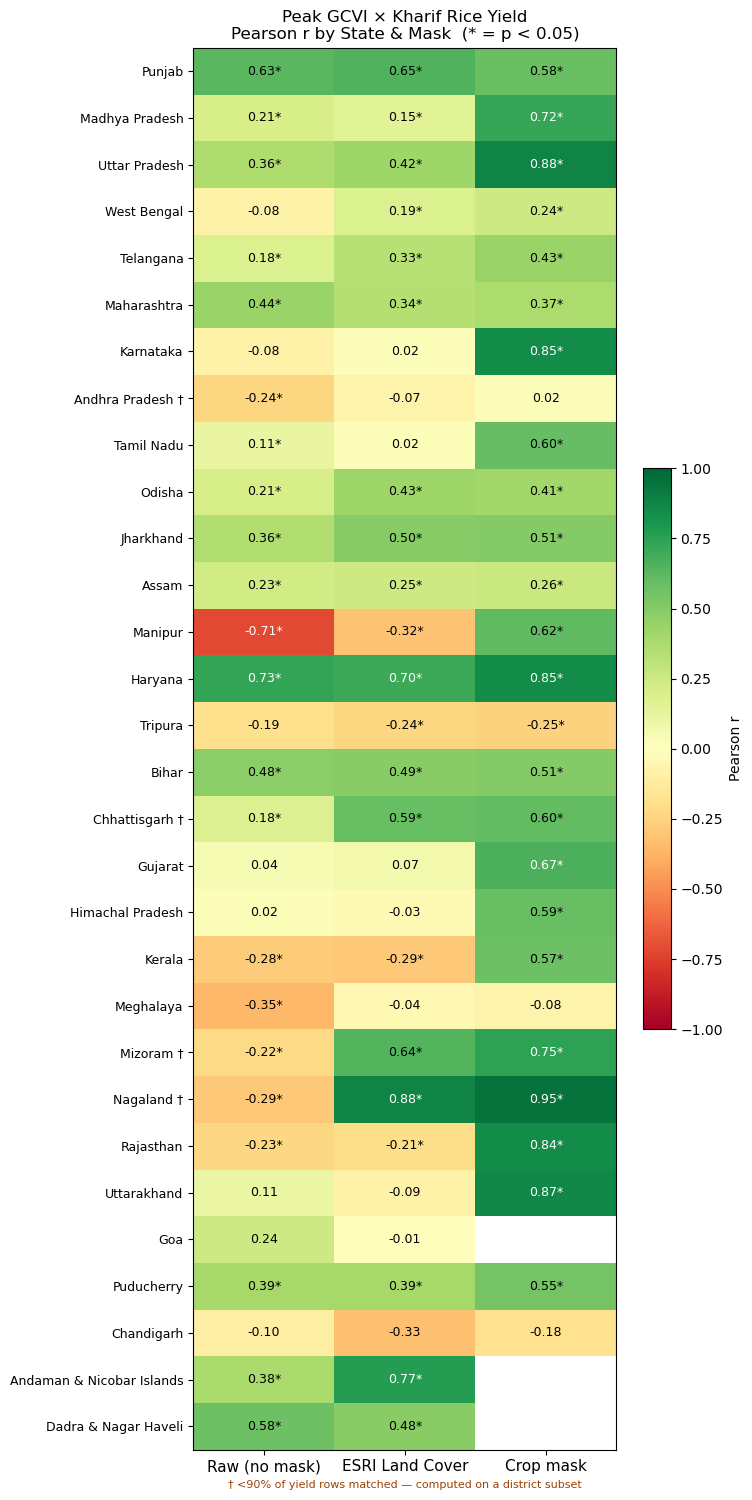

In [5]:
MASK_LABELS = {
    'raw':   'Raw (no mask)',
    'esri':  'ESRI Land Cover',
    'crop':  'Crop mask',   # Punjab / MP naming
    'jordi': 'Crop mask',   # all other states — same product
}
MASK_COLORS = {
    'raw':   'steelblue',
    'esri':  'darkorange',
    'crop':  'mediumseagreen',
    'jordi': 'mediumseagreen',
}

# ── Heatmap: Pearson r — 3 logical columns (crop & jordi share one column) ──
heatmap_cols   = ['raw', 'esri', 'crop/jordi']
heatmap_labels = ['Raw (no mask)', 'ESRI Land Cover', 'Crop mask']

region_list = [r for r in REGION_LABELS if r in set(corr_state_df['region'])]

r_mat   = np.full((len(region_list), len(heatmap_cols)), np.nan)
sig_mat = np.zeros((len(region_list), len(heatmap_cols)), dtype=bool)
low_cov = set()

for i, region in enumerate(region_list):
    for j, col_key in enumerate(heatmap_cols):
        masks_to_try = ['crop', 'jordi'] if col_key == 'crop/jordi' else [col_key]
        for mask in masks_to_try:
            row = corr_state_df[(corr_state_df['region'] == region) &
                                (corr_state_df['mask']   == mask)]
            if len(row):
                r_mat[i, j]   = row['r'].values[0]
                sig_mat[i, j] = row['p'].values[0] < 0.05
                if row['yield_coverage_pct'].values[0] < 90:
                    low_cov.add(region)
                break

fig, ax = plt.subplots(figsize=(7.5, 0.42 * len(region_list) + 2.5))
im = ax.imshow(r_mat, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')

for i in range(len(region_list)):
    for j in range(len(heatmap_cols)):
        if not np.isnan(r_mat[i, j]):
            txt   = f"{r_mat[i, j]:.2f}" + ('*' if sig_mat[i, j] else '')
            color = 'white' if abs(r_mat[i, j]) > 0.65 else 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=9, color=color)

# mark partial-coverage states with a dagger so a low r is read in context
ylabels = [REGION_LABELS[r] + (' †' if r in low_cov else '') for r in region_list]

ax.set_xticks(range(len(heatmap_cols)))
ax.set_xticklabels(heatmap_labels, fontsize=11)
ax.set_yticks(range(len(region_list)))
ax.set_yticklabels(ylabels, fontsize=9)
plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.4)
ax.set_title('Peak GCVI × Kharif Rice Yield\n'
             'Pearson r by State & Mask  (* = p < 0.05)', fontsize=12)
if low_cov:
    ax.set_xlabel('† <90% of yield rows matched — computed on a district subset',
                  fontsize=8, color='#a04000')
plt.tight_layout()
plt.savefig('../../outputs/gcvi_yield_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_5735/288741557.py:43: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  states_gdf['_area'] = states_gdf.geometry.area


Colour scale: ±1.24   (values beyond are clipped)
Too small to label on the map: Goa, Puducherry, Chandigarh, Dadra & Nagar Haveli



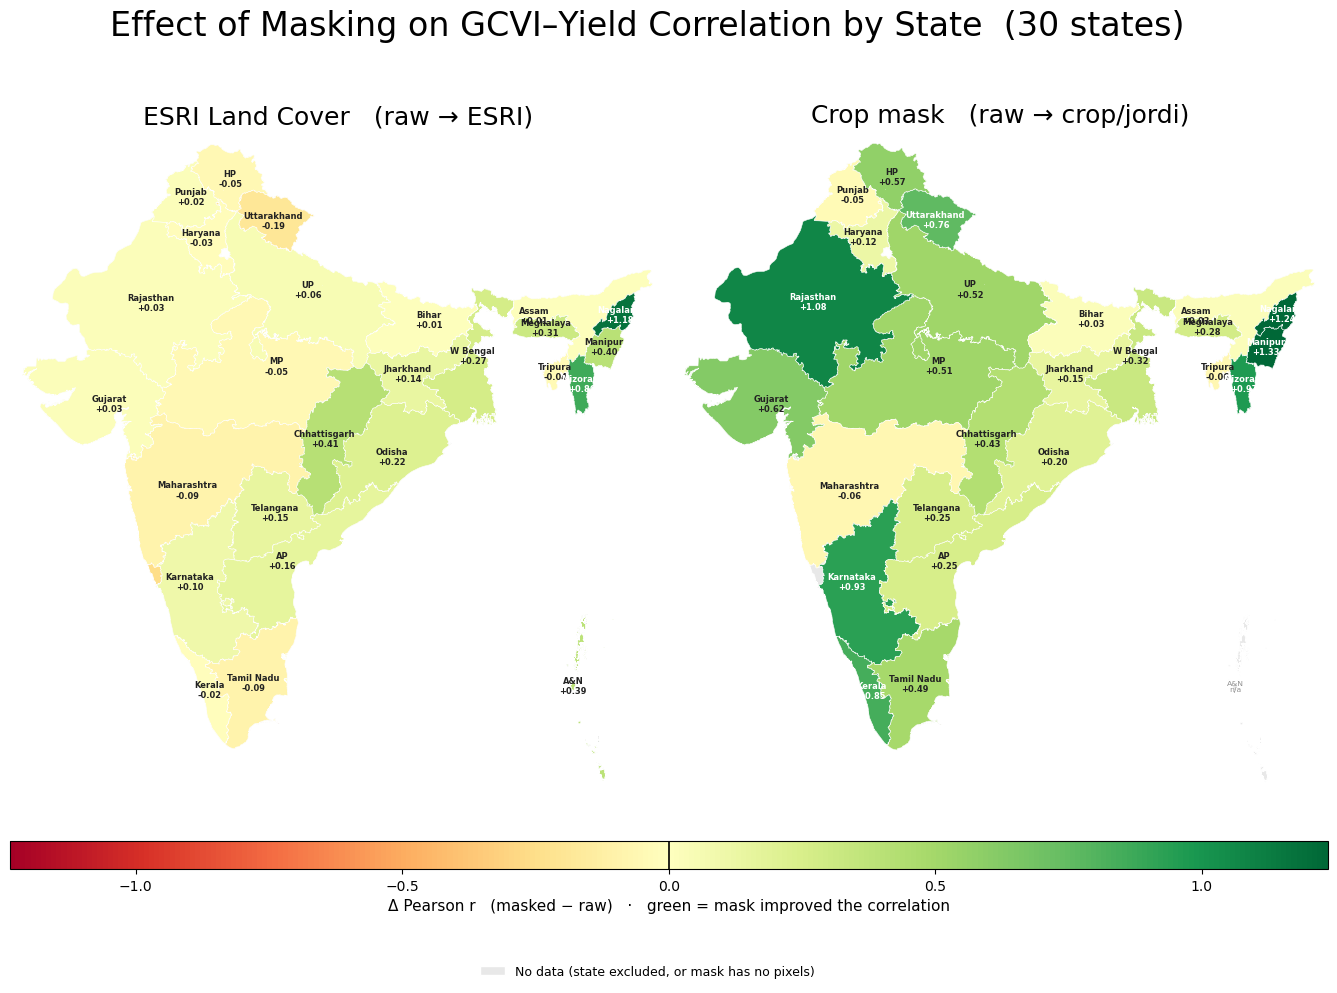


ESRI Land Cover   (raw → ESRI)
  most improved : Nagaland +1.18, Mizoram +0.86, Chhattisgarh +0.41
  most degraded : Goa -0.26, Chandigarh -0.22, Uttarakhand -0.19
  improved: 18/30 states
  (unlabelled on map) Goa -0.26, Chandigarh -0.22, Dadra & Nagar Haveli -0.09, Puducherry +0.00

Crop mask   (raw → crop/jordi)
  most improved : Manipur +1.33, Nagaland +1.24, Rajasthan +1.08
  most degraded : Chandigarh -0.08, Maharashtra -0.06, Tripura -0.06
  improved: 23/27 states
  (unlabelled on map) Chandigarh -0.08, Puducherry +0.16


In [9]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

# ── build state-level geometry by dissolving each state's district file ────
def state_geometry(region_keys):
    rows = []
    for k in region_keys:
        g = gpd.read_file(REGIONS[k]['shp']).to_crs('EPSG:4326')
        g = g[g.geometry.notna() & ~g.geometry.is_empty]
        # Andaman is stored as GeometryCollection — explode before dissolving
        if (g.geometry.geom_type == 'GeometryCollection').any():
            g = g.explode(index_parts=False)
            g = g[g.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])]
        if len(g):
            rows.append({'region_key': k, 'geometry': g.geometry.union_all()})
    return gpd.GeoDataFrame(rows, crs='EPSG:4326')

states_gdf = state_geometry(list(REGIONS))
states_gdf = states_gdf.merge(
    delta_df[['region_key', 'region', 'baseline_r', 'delta_esri', 'delta_crop',
              'yield_coverage_pct']],
    on='region_key', how='left')

# short labels so long names fit inside the smaller states
SHORT_NAME = {
    'Madhya Pradesh':            'MP',
    'Uttar Pradesh':             'UP',
    'Andhra Pradesh':            'AP',
    'Himachal Pradesh':          'HP',
    'West Bengal':               'W Bengal',
    'Andaman & Nicobar Islands': 'A&N',
    'Dadra & Nagar Haveli':      'D&NH',
}
states_gdf['label'] = states_gdf['region'].map(lambda s: SHORT_NAME.get(s, s))

# ── shared symmetric colour scale so the two panels are comparable ─────────
allv       = pd.concat([states_gdf['delta_esri'], states_gdf['delta_crop']]).dropna()
lim        = np.nanpercentile(np.abs(allv), 98)
vmin, vmax = -lim, lim

# Tiny territories are unreadable on a national map — list them below instead.
MIN_LABEL_AREA = 0.35          # square degrees
states_gdf['_area'] = states_gdf.geometry.area
too_small = states_gdf.loc[states_gdf['_area'] < MIN_LABEL_AREA, 'region'].tolist()

print(f"Colour scale: ±{lim:.2f}   (values beyond are clipped)")
if too_small:
    print(f"Too small to label on the map: {', '.join(too_small)}\n")

PANELS = [('delta_esri', 'ESRI Land Cover   (raw → ESRI)'),
          ('delta_crop', 'Crop mask   (raw → crop/jordi)')]

# India's extent, applied to both panels so they align exactly
minx, miny, maxx, maxy = states_gdf.total_bounds
padx, pady = 0.02 * (maxx - minx), 0.02 * (maxy - miny)

fig = plt.figure(figsize=(17, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[26, 1],
                        hspace=0.04, wspace=0.01)

for j, (col, title) in enumerate(PANELS):
    ax = fig.add_subplot(gs[0, j])

    # grey basemap first so no-data states stay visible, values drawn on top
    states_gdf.plot(ax=ax, color='#e8e8e8', edgecolor='white', linewidth=0.4)
    sub = states_gdf[states_gdf[col].notna()]
    sub.plot(column=col, ax=ax, cmap='RdYlGn', vmin=vmin, vmax=vmax,
             edgecolor='white', linewidth=0.4)

    # two-line label: state name on top, Δr beneath
    for _, row in states_gdf.iterrows():
        if row['_area'] < MIN_LABEL_AREA:
            continue
        pt  = row.geometry.representative_point()
        val = row[col]

        if pd.isna(val):
            ax.annotate(f"{row['label']}\nn/a", (pt.x, pt.y),
                        ha='center', va='center', fontsize=5.5,
                        color='#909090', linespacing=1.1)
            continue

        # white text on saturated fills, dark on pale ones
        shade = 'white' if abs(val) > 0.55 * lim else '#222222'
        ax.annotate(f"{row['label']}\n{val:+.2f}", (pt.x, pt.y),
                    ha='center', va='center', fontsize=6, color=shade,
                    weight='bold', linespacing=1.15)

    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)
    ax.set_title(title, fontsize=18, pad=6)
    ax.axis('off')

# ── one shared horizontal colorbar spanning both maps ─────────────────────
cbar_ax = fig.add_subplot(gs[1, :])
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Δ Pearson r   (masked − raw)   ·   green = mask improved the correlation',
               fontsize=11)
cbar_ax.axvline(0, color='black', linewidth=1.2)

fig.legend(handles=[Patch(facecolor='#e8e8e8', edgecolor='white',
                          label='No data (state excluded, or mask has no pixels)')],
           loc='lower center', bbox_to_anchor=(0.5, -0.01), fontsize=9, frameon=False)

fig.suptitle(f'Effect of Masking on GCVI–Yield Correlation by State  ({len(states_gdf)} states)',
             fontsize=24, y=0.97)
plt.savefig('../../outputs/map_delta_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

# ── extremes + the states omitted from the map labels ─────────────────────
for col, title in PANELS:
    s = states_gdf[['region', col]].dropna().sort_values(col)
    print(f"\n{title}")
    print('  most improved : ' + ', '.join(f"{r['region']} {r[col]:+.2f}"
                                           for _, r in s.tail(3)[::-1].iterrows()))
    print('  most degraded : ' + ', '.join(f"{r['region']} {r[col]:+.2f}"
                                           for _, r in s.head(3).iterrows()))
    print(f'  improved: {(s[col] > 0).sum()}/{len(s)} states')
    small = s[s['region'].isin(too_small)]
    if len(small):
        print('  (unlabelled on map) ' + ', '.join(f"{r['region']} {r[col]:+.2f}"
                                                   for _, r in small.iterrows()))

## Correlation Improvement vs District Agreement

All plots below use **signed Pearson r**, drawn twice — raw → ESRI on the left, raw → crop mask on the right, on shared axes.

- **Δr** = `masked_r − raw_r` — the absolute change in correlation.
- **Relative improvement** = `Δr / (1 − baseline_r)` — the share of the available headroom the mask captured.

In [6]:
dist_agreement_df = pd.read_csv("../../data/district_agreement_for_gee.csv")
dist_agreement_df.columns

Index(['State', 'District', 'agreement', 'agreement_Peas', 'census_Peas_ha',
       'pred_Peas_ha', 'agreement_Maize', 'census_Maize_ha', 'pred_Maize_ha',
       'agreement_Rice', 'census_Rice_ha', 'pred_Rice_ha', 'agreement_Cotton',
       'census_Cotton_ha', 'pred_Cotton_ha', 'agreement_Sugarcane',
       'census_Sugarcane_ha', 'pred_Sugarcane_ha', 'census_total_ha',
       'pred_total_ha'],
      dtype='object')

In [7]:
dist_agreement_df[dist_agreement_df['State'] == 'Andhra Pradesh']['agreement_Rice'].mean()

0.8298076923076925

In [8]:
import pandas as pd
corr_state_df     = pd.read_csv('../../outputs/gcvi_yield_correlation.csv')
dist_agreement_df = pd.read_csv("../../data/district_agreement_for_gee.csv")

delta_arr = []
for region in REGIONS.keys():
    sub  = corr_state_df[corr_state_df['region'] == region]
    raw  = sub[sub['mask'] == 'raw']['r'].values
    esri = sub[sub['mask'] == 'esri']['r'].values
    crop = sub[sub['mask'].isin(['crop', 'jordi'])]['r'].values

    agree = dist_agreement_df[dist_agreement_df['State'] == REGION_LABELS[region]]['agreement_Rice']

    delta_arr.append({
        'region':      REGION_LABELS[region],
        'region_key':  region,
        'baseline_r':  next(iter(raw), np.nan),
        'delta_esri':  next(iter(esri - raw), np.nan),
        'delta_crop':  next(iter(crop - raw), np.nan),
        'district_agreement_crop_mean': agree.mean(),
        'district_agreement_crop_std':  agree.std(),
        'yield_coverage_pct': next(iter(sub['yield_coverage_pct'].values), np.nan),
    })

delta_df = pd.DataFrame(delta_arr)

# Relative improvement = share of the available headroom (1 - baseline_r) the
# mask actually captured. Computed for BOTH masks so they compare on equal terms.
for m in ('esri', 'crop'):
    delta_df[f'rel_improvement_{m}'] = delta_df[f'delta_{m}'] / (1 - delta_df['baseline_r'])

delta_df['district_agreement_crop_mean_std_ratio'] = (
    delta_df['district_agreement_crop_mean'] / delta_df['district_agreement_crop_std'])

# ── the two mask steps compared throughout the rest of the notebook ────────
#    both are measured as an improvement over the SAME raw baseline
MASK_PANELS = [
    ('esri', 'ESRI Land Cover  (raw → ESRI)'),
    ('crop', 'Crop mask  (raw → crop/jordi)'),
]

delta_df.to_csv('../../outputs/delta_improvement.csv', index=False)

print(f"{'state':<28}{'baseline':>9}{'Δesri':>8}{'Δcrop':>8}{'rel_esri':>10}{'rel_crop':>10}")
print('-' * 73)
for _, r in delta_df.sort_values('delta_esri', ascending=False).iterrows():
    print(f"{r['region']:<28}{r['baseline_r']:>9.3f}{r['delta_esri']:>8.3f}{r['delta_crop']:>8.3f}"
          f"{r['rel_improvement_esri']:>10.3f}{r['rel_improvement_crop']:>10.3f}")

print(f"\nMean Δ:  esri {delta_df['delta_esri'].mean():+.3f}   "
      f"crop {delta_df['delta_crop'].mean():+.3f}")
print(f"Improved (Δ>0):  esri {(delta_df['delta_esri'] > 0).sum()}/{delta_df['delta_esri'].notna().sum()}   "
      f"crop {(delta_df['delta_crop'] > 0).sum()}/{delta_df['delta_crop'].notna().sum()}")

delta_df

state                        baseline   Δesri   Δcrop  rel_esri  rel_crop
-------------------------------------------------------------------------
Nagaland                       -0.294   1.176   1.244     0.909     0.961
Mizoram                        -0.220   0.864   0.968     0.708     0.793
Chhattisgarh                    0.177   0.413   0.427     0.502     0.519
Manipur                        -0.711   0.396   1.328     0.231     0.776
Andaman & Nicobar Islands       0.379   0.392     nan     0.631       nan
Meghalaya                      -0.355   0.311   0.279     0.230     0.206
West Bengal                    -0.079   0.266   0.323     0.247     0.299
Odisha                          0.206   0.222   0.202     0.280     0.254
Andhra Pradesh                 -0.236   0.163   0.254     0.132     0.206
Telangana                       0.180   0.153   0.254     0.187     0.310
Jharkhand                       0.357   0.139   0.149     0.216     0.232
Karnataka                      -0.080 

,region,region_key,baseline_r,delta_esri,delta_crop,district_agreement_crop_mean,district_agreement_crop_std,yield_coverage_pct,rel_improvement_esri,rel_improvement_crop,district_agreement_crop_mean_std_ratio
0,Punjab,punjab,0.628,0.022,-0.045,0.911557,0.054849,98.5,0.059140,-0.120968,16.619321
1,Madhya Pradesh,mp,0.210,-0.055,0.514,0.608773,0.287984,99.5,-0.069620,0.650633,2.113913
2,Uttar Pradesh,up,0.363,0.056,0.516,0.888172,0.176557,98.7,0.087912,0.810047,5.030509
3,West Bengal,wb,-0.079,0.266,0.323,0.875643,0.114179,100.0,0.246525,0.299351,7.669047
4,Telangana,telangana,0.180,0.153,0.254,0.884225,0.175078,100.0,0.186585,0.309756,5.050458
5,Maharashtra,maharashtra,0.437,-0.094,-0.064,0.422544,0.399393,100.0,-0.166963,-0.113677,1.057966
6,Karnataka,karnataka,-0.080,0.099,0.927,0.723250,0.270171,95.9,0.091667,0.858333,2.677010
7,Andhra Pradesh,andhra_pradesh,-0.236,0.163,0.254,0.829808,0.144903,80.0,0.131877,0.205502,5.726655
8,Tamil Nadu,tamil_nadu,0.112,-0.092,0.486,0.579792,0.344496,98.7,-0.103604,0.547297,1.683017
9,Odisha,odisha,0.206,0.222,0.202,0.929957,0.049849,100.0,0.279597,0.254408,18.655412


⚠ 1 states still 'unclassified' — they plot in grey. Assign them in LANDCOVER_CLASS above.



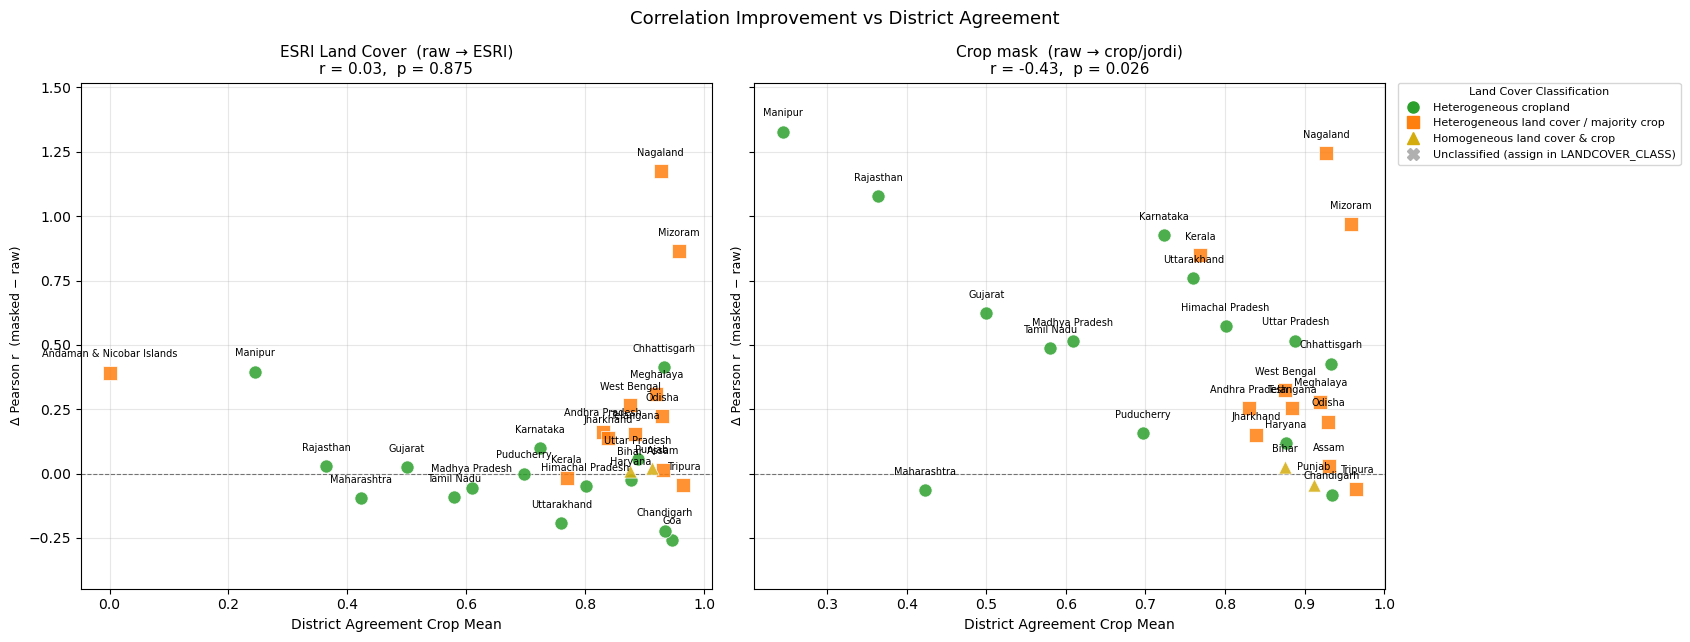

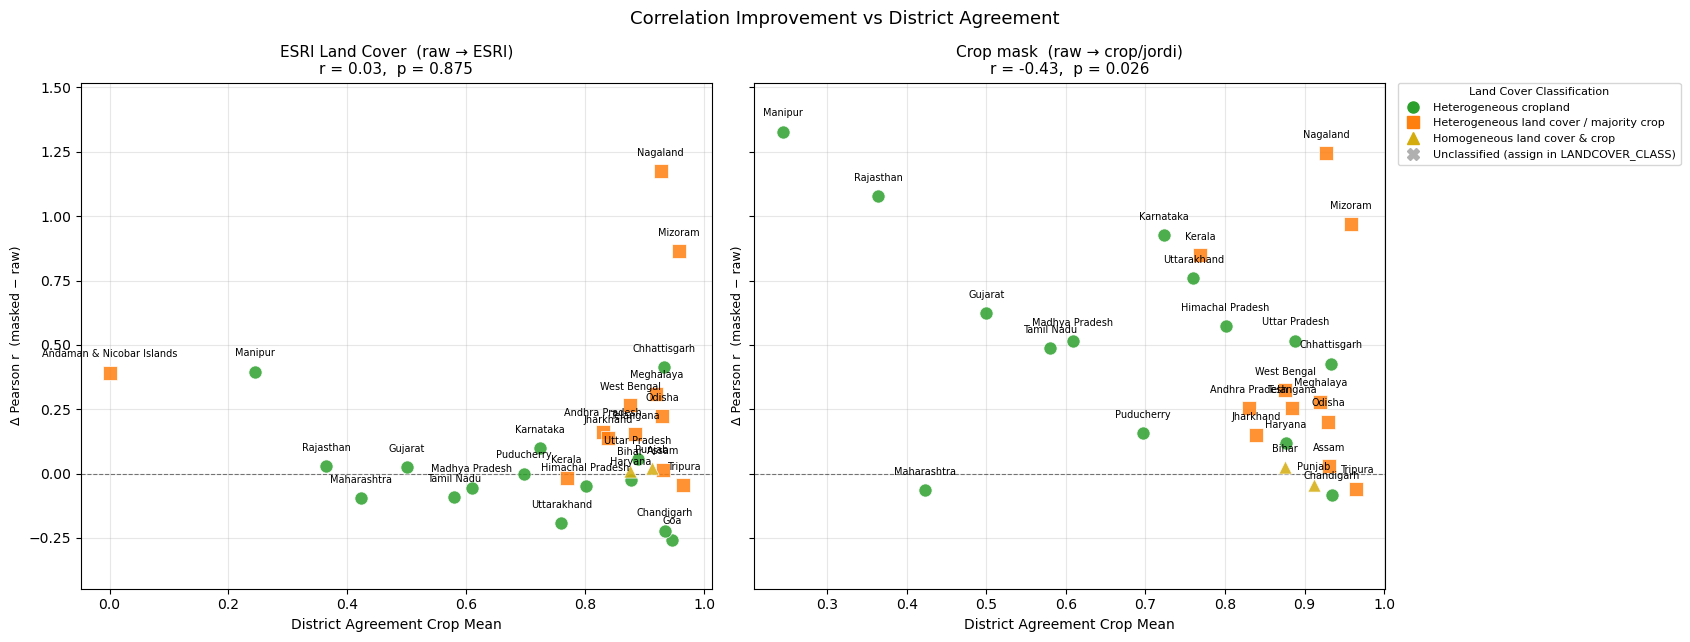

In [10]:
## Further Analysis: Correlation Improvement vs District Agreement
#  Every plot below is drawn TWICE — once for the raw → ESRI step, once for
#  raw → crop mask — so the two masks are compared on identical axes.

from matplotlib.lines import Line2D

# ⚠ TODO: the 15 states below the divider are UNCLASSIFIED — I did not want to
# guess their land-cover character on your behalf. They plot in grey until you
# assign each to 'homogeneous', 'heterogeneous_crop', or 'heterogeneous_lc'.
LANDCOVER_CLASS = {
    'Punjab':         'homogeneous',
    'Madhya Pradesh': 'heterogeneous_crop',
    'Uttar Pradesh':  'heterogeneous_crop',
    'West Bengal':    'heterogeneous_lc',
    'Telangana':      'heterogeneous_lc',
    'Maharashtra':    'heterogeneous_crop',
    'Karnataka':      'heterogeneous_crop',
    'Andhra Pradesh': 'heterogeneous_lc',
    'Tamil Nadu':     'heterogeneous_crop',
    'Odisha':         'heterogeneous_lc',
    'Jharkhand':      'heterogeneous_lc',
    'Assam':          'heterogeneous_lc',
    'Manipur':        'heterogeneous_crop',
    'Haryana':        'heterogeneous_crop',
    'Tripura':        'heterogeneous_lc',
    # ── classify these ────────────────────────────────────────────────────
    'Bihar':                     'homogeneous',
    'Chhattisgarh':              'heterogeneous_crop',
    'Gujarat':                   'heterogeneous_crop',
    'Himachal Pradesh':          'heterogeneous_crop',
    'Kerala':                    'heterogeneous_lc',
    'Meghalaya':                 'heterogeneous_lc',
    'Mizoram':                   'heterogeneous_lc',
    'Nagaland':                  'heterogeneous_lc',
    'Rajasthan':                 'heterogeneous_crop',
    'Uttarakhand':               'heterogeneous_crop',
    'Goa':                       'heterogeneous_crop',
    'Puducherry':                'heterogeneous_crop',
    'Chandigarh':                'heterogeneous_crop',
    'Andaman & Nicobar Islands': 'heterogeneous_lc',
    'Dadra & Nagar Haveli':      'unclassified',
}

CLASS_STYLE = {
    'heterogeneous_crop': {'color': '#2ca02c', 'marker': 'o', 'label': 'Heterogeneous cropland'},
    'heterogeneous_lc':   {'color': '#ff7f0e', 'marker': 's', 'label': 'Heterogeneous land cover / majority crop'},
    'homogeneous':        {'color': '#d4ac0d', 'marker': '^', 'label': 'Homogeneous land cover & crop'},
    'unclassified':       {'color': '#b0b0b0', 'marker': 'X', 'label': 'Unclassified (assign in LANDCOVER_CLASS)'},
}

n_unclassified = sum(1 for v in LANDCOVER_CLASS.values() if v == 'unclassified')
if n_unclassified:
    print(f"⚠ {n_unclassified} states still 'unclassified' — they plot in grey. "
          f"Assign them in LANDCOVER_CLASS above.\n")


def plot_mask_panels(df, xcol, ycol_prefix, xlabel, ylabel, suptitle,
                     fname=None, size_col=None, size_scale=800,
                     annotate=True, share_y=True):
    """Two side-by-side scatters — ESRI delta (left) vs crop delta (right).

    ycol_prefix : 'delta' or 'rel_improvement'; the mask key is appended.
    Panel titles carry the Pearson r between xcol and that panel's y.
    """
    fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), sharey=share_y)

    # common y-limits so the two panels are visually comparable
    if share_y:
        allv = pd.concat([df[f'{ycol_prefix}_{m}'] for m, _ in MASK_PANELS]).dropna()
        pad  = 0.12 * (allv.max() - allv.min())
        ylim = (allv.min() - pad, allv.max() + pad)

    for ax, (mkey, mlabel) in zip(axes, MASK_PANELS):
        ycol = f'{ycol_prefix}_{mkey}'
        for cls, style in CLASS_STYLE.items():
            sub = df[df['region'].map(LANDCOVER_CLASS) == cls].dropna(subset=[xcol, ycol])
            if sub.empty:
                continue
            ax.scatter(sub[xcol], sub[ycol],
                       s=(sub[size_col].fillna(0.5) * size_scale if size_col else 90),
                       color=style['color'], marker=style['marker'],
                       alpha=0.85, edgecolors='white', linewidths=0.6, zorder=3)

        if annotate:
            for _, row in df.dropna(subset=[xcol, ycol]).iterrows():
                ax.annotate(row['region'], (row[xcol], row[ycol]),
                            textcoords="offset points", xytext=(0, 11),
                            ha='center', fontsize=7)

        valid = df[[xcol, ycol]].dropna()
        rr, pp = stats.pearsonr(valid[xcol], valid[ycol]) if len(valid) > 2 else (np.nan, np.nan)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.set_title(f'{mlabel}\nr = {rr:.2f},  p = {pp:.3f}', fontsize=11)
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(alpha=0.3)
        if share_y:
            ax.set_ylim(*ylim)

    handles = [Line2D([0], [0], marker=s['marker'], color='w',
                      markerfacecolor=s['color'], markeredgecolor=s['color'],
                      markersize=8, label=s['label'])
               for s in CLASS_STYLE.values()]
    axes[1].legend(handles=handles, title='Land Cover Classification',
                   fontsize=8, title_fontsize=8,
                   loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)

    fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    if fname:
        plt.savefig(f'../../outputs/{fname}', dpi=150, bbox_inches='tight')
    plt.show()
    return fig


# ── Plot 1: absolute delta vs district agreement ───────────────────────────
plot_mask_panels(
    delta_df,
    xcol='district_agreement_crop_mean',
    ycol_prefix='delta',
    xlabel='District Agreement Crop Mean',
    ylabel='Δ Pearson r  (masked − raw)',
    suptitle='Correlation Improvement vs District Agreement',
    fname='delta_vs_agreement.png',
)

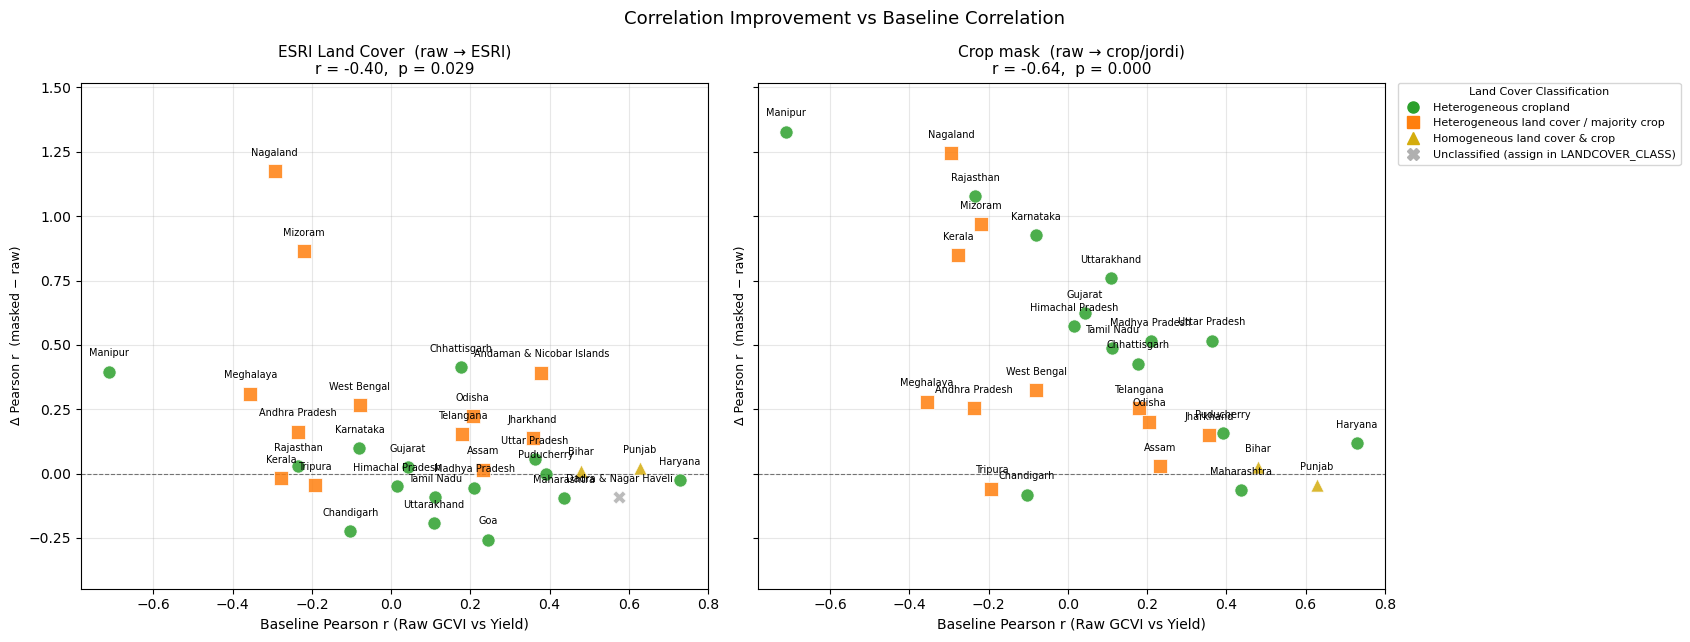

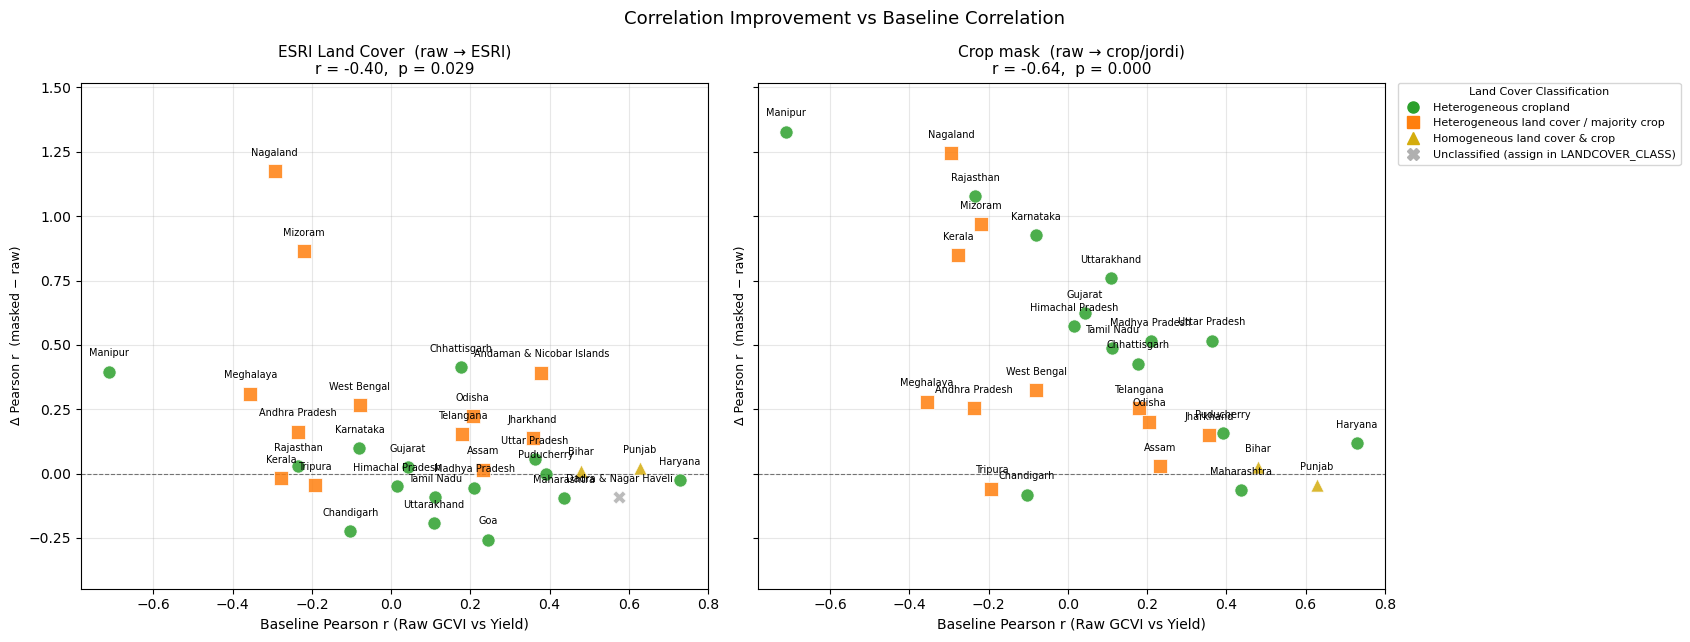

In [11]:
# ── Plot 2: absolute delta vs baseline correlation ─────────────────────────
plot_mask_panels(
    delta_df,
    xcol='baseline_r',
    ycol_prefix='delta',
    xlabel='Baseline Pearson r (Raw GCVI vs Yield)',
    ylabel='Δ Pearson r  (masked − raw)',
    suptitle='Correlation Improvement vs Baseline Correlation',
    fname='delta_vs_baseline.png',
)

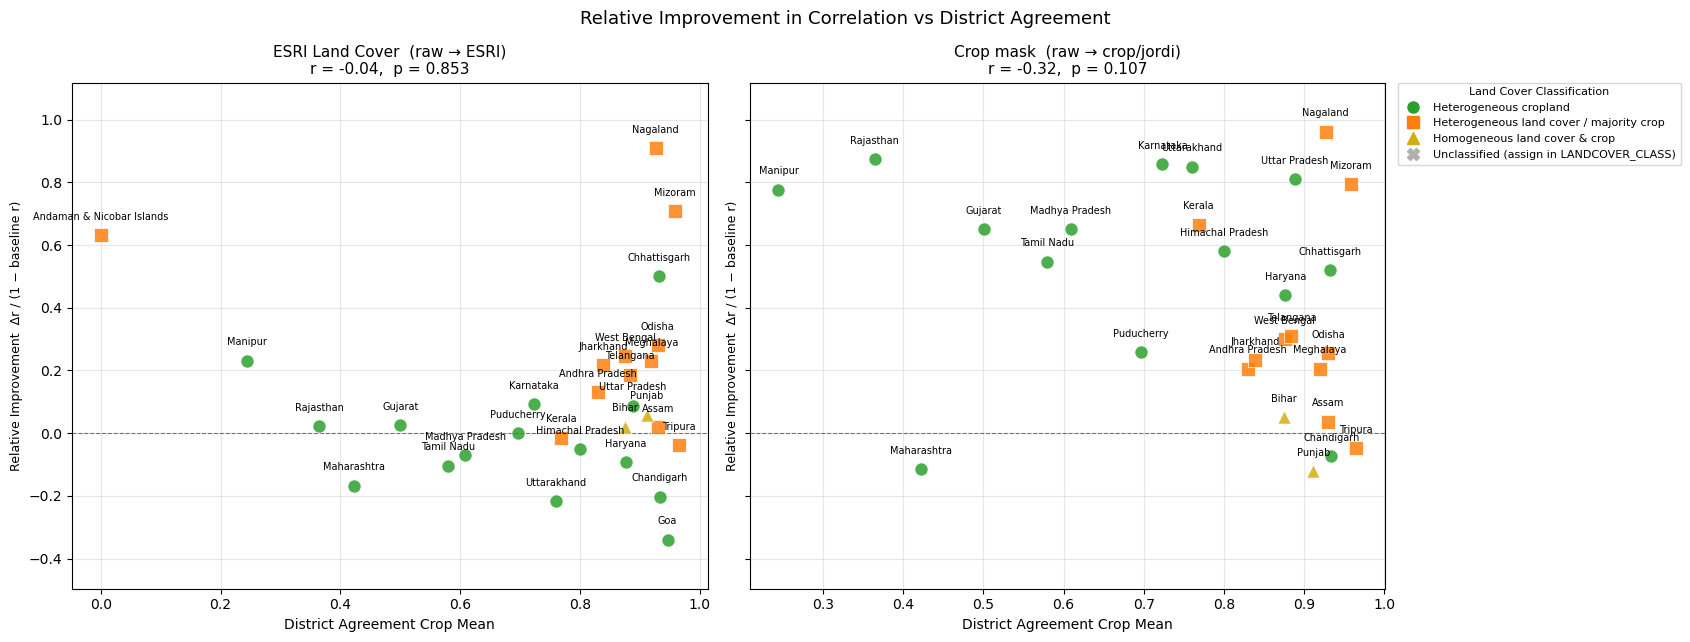

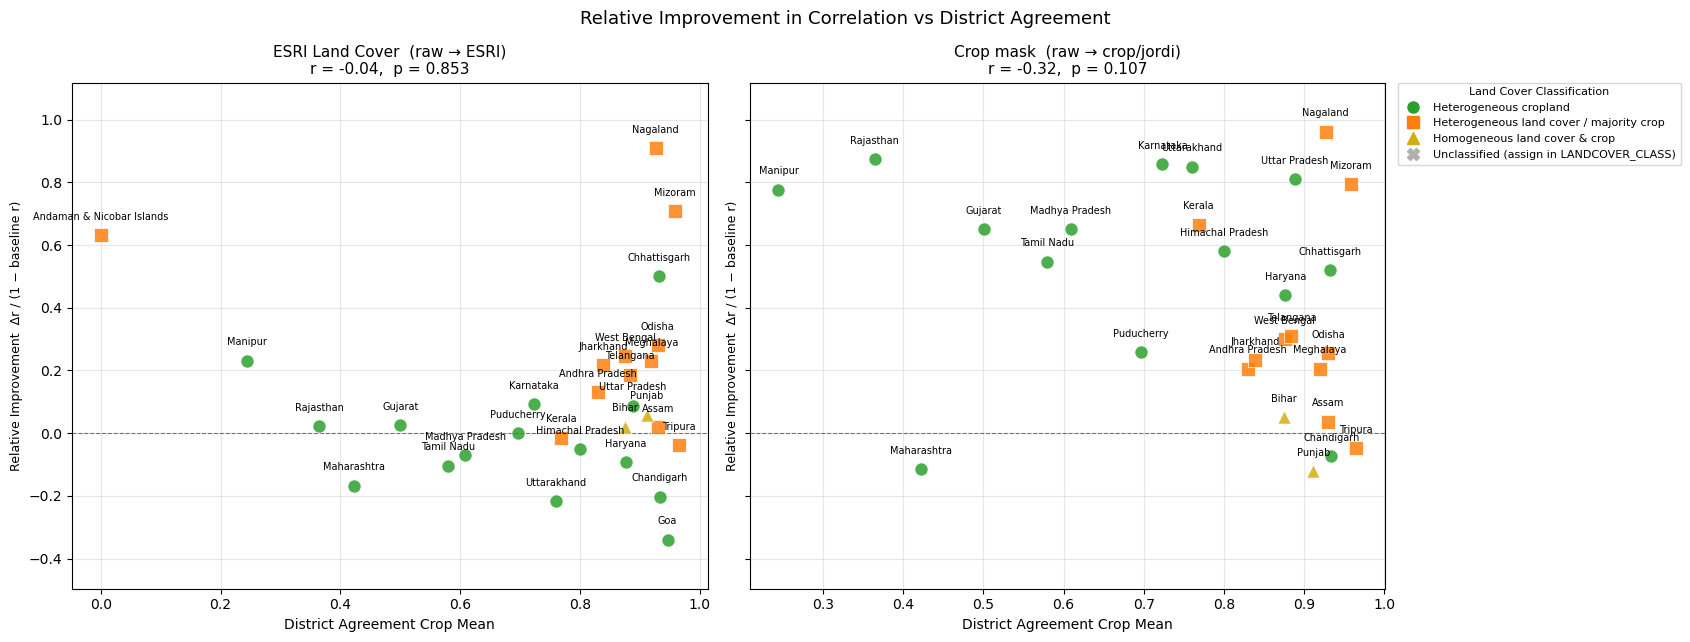

In [12]:
# ── Plot 3: RELATIVE improvement vs district agreement ─────────────────────
#    rel = Δr / (1 - baseline_r)  →  share of available headroom captured
plot_mask_panels(
    delta_df,
    xcol='district_agreement_crop_mean',
    ycol_prefix='rel_improvement',
    xlabel='District Agreement Crop Mean',
    ylabel='Relative Improvement  Δr / (1 − baseline r)',
    suptitle='Relative Improvement in Correlation vs District Agreement',
    fname='rel_improvement_vs_agreement.png',
)

There is clear story from the figure above. The states with homogeneous land cover do not reap the same benefits of a crop mask as those with heterogeneous land cover or cropland. The relative improvement is negative which means that the Pearson r stat decreased once the mask was incorporated. The district agreement crop mean doesn't seem to affect the amount of decrease in the Pearson coefficient. This decrease can be associated with the 

In [ ]:
## Rice-Fraction CV vs CV of District Crop Entropy
#  Two heterogeneity metrics compared head-to-head as predictors of how much
#  each mask improves the GCVI–yield correlation.
#    left  : CV of rice fraction across districts   (unevenness of rice area)
#    right : CV of district crop entropy            (unevenness of crop diversity)
#  Rows = mask step (ESRI top / crop bottom).

import glob
from matplotlib.lines import Line2D

# ── 1. rice fraction: mean and CV across the districts of each state ───────
dist_agreement_df['rice_fraction'] = (
    dist_agreement_df['census_Rice_ha'] / dist_agreement_df['census_total_ha'])

rice_het = (
    dist_agreement_df.groupby('State')['rice_fraction']
    .agg(rice_fraction_mean='mean',
         rice_fraction_cv=lambda x: x.std() / x.mean() if x.mean() else np.nan)
    .reset_index()
    .rename(columns={'State': 'region'})
)

# ── 2. district-level crop entropy, aggregated per state ───────────────────
#    entropy_mean = plain mean of district entropies (the metric plotted).
#    The state CSV also carries an AREA-WEIGHTED version
#    (crop_entropy_district_avg) — both appear in the table at the bottom.
ENT_DIR = '../../data/crop_entropy'

ent_rows = []
for path in sorted(glob.glob(f'{ENT_DIR}/*_CropEntropy_District.csv')):
    key = os.path.basename(path).replace('_CropEntropy_District.csv', '')
    d   = pd.read_csv(path, usecols=['crop_entropy_district', 'gaul2_name'])
    e   = pd.to_numeric(d['crop_entropy_district'], errors='coerce').dropna()
    if len(e) == 0:
        continue
    ent_rows.append({
        'entropy_key':   key,
        'n_ent_dist':    len(e),
        'entropy_mean':  e.mean(),
        'entropy_std':   e.std(),
        'entropy_cv':    e.std() / e.mean() if e.mean() else np.nan,
    })
district_ent = pd.DataFrame(ent_rows)

state_ent = (pd.read_csv('crop_entropy_by_state.csv')
             .rename(columns={'state': 'entropy_key'})
             [['entropy_key', 'crop_entropy_state', 'crop_entropy_district_avg']])

# the entropy files spell West Bengal 'west_bengal'; REGIONS uses 'wb'
ENTROPY_KEY_ALIAS = {'wb': 'west_bengal'}

plot_df = delta_df.merge(rice_het, on='region', how='left')
plot_df['entropy_key'] = plot_df['region_key'].replace(ENTROPY_KEY_ALIAS)
plot_df = (plot_df
           .merge(state_ent,    on='entropy_key', how='left')
           .merge(district_ent, on='entropy_key', how='left'))

missing = plot_df.loc[plot_df['entropy_mean'].isna(), 'region'].tolist()
if missing:
    print(f"⚠ no district-level entropy for: {', '.join(missing)}\n")

# ── plot: the two metrics being compared ───────────────────────────────────
SIZE_SCALE = 800
XCOLS = [
    ('rice_fraction_cv', 'CV of Rice Fraction across Districts\n(how unevenly rice is spread)'),
    ('entropy_cv',       'CV of District Crop Entropy\n(how unevenly diversity is spread)'),
]

fig, axes = plt.subplots(2, len(XCOLS), figsize=(9 * len(XCOLS), 12), sharey='row')

for i, (mkey, mlabel) in enumerate(MASK_PANELS):
    ycol = f'rel_improvement_{mkey}'

    for j, (xcol, xlabel) in enumerate(XCOLS):
        ax = axes[i, j]
        for cls, style in CLASS_STYLE.items():
            sub = (plot_df[plot_df['region'].map(LANDCOVER_CLASS) == cls]
                   .dropna(subset=[xcol, ycol]))
            if sub.empty:
                continue
            ax.scatter(
                sub[xcol], sub[ycol],
                s=sub['district_agreement_crop_mean'].fillna(0.5) * SIZE_SCALE,
                color=style['color'], marker=style['marker'],
                alpha=0.8, edgecolors='white', linewidths=0.6, zorder=3,
            )
        for _, row in plot_df.dropna(subset=[xcol, ycol]).iterrows():
            ax.annotate(row['region'], (row[xcol], row[ycol]),
                        textcoords="offset points", xytext=(0, 10),
                        ha='center', fontsize=7)

        valid  = plot_df[[xcol, ycol]].dropna()
        rr, pp = stats.pearsonr(valid[xcol], valid[ycol]) if len(valid) > 2 else (np.nan, np.nan)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        star = ' *' if pp < 0.05 else ''
        ax.set_title(f'{mlabel}\nr = {rr:.2f}, p = {pp:.3f}{star}   (n={len(valid)})',
                     fontsize=11)
        ax.set_xlabel(xlabel, fontsize=10)
        if j == 0:
            ax.set_ylabel('Relative Improvement\nΔr / (1 − baseline r)', fontsize=9)
        ax.grid(alpha=0.3)

# ── legends outside the right-hand panels ──────────────────────────────────
class_handles = [
    Line2D([0], [0], marker=s['marker'], color='w',
           markerfacecolor=s['color'], markeredgecolor=s['color'],
           markersize=7, label=s['label'])
    for s in CLASS_STYLE.values()
]
leg1 = axes[0, -1].legend(handles=class_handles, title='Land Cover Classification',
                          fontsize=8, title_fontsize=8,
                          loc='upper left', bbox_to_anchor=(1.02, 1.0),
                          borderaxespad=0, frameon=True)
axes[0, -1].add_artist(leg1)

size_handles = [
    plt.scatter([], [], s=v * SIZE_SCALE, color='gray', alpha=0.7, label=f'{v:.1f}')
    for v in [0.3, 0.6, 0.9]
]
axes[1, -1].legend(handles=size_handles, title='District Crop\nAgreement (size)',
                   fontsize=8, title_fontsize=8,
                   loc='upper left', bbox_to_anchor=(1.02, 1.0),
                   borderaxespad=0, frameon=True, labelspacing=1.4)

fig.suptitle('Rice-Fraction CV vs District-Entropy CV — ESRI (top) vs Crop mask (bottom)',
             fontsize=13)
plt.tight_layout(rect=[0, 0, 0.87, 0.98])
plt.savefig('../../outputs/cv_vs_entropy_rel_improvement.png', dpi=150, bbox_inches='tight')
plt.show()

# ── how the two metrics relate to each other ───────────────────────────────
pair = plot_df[['rice_fraction_cv', 'entropy_cv']].dropna()
rr, pp = stats.pearsonr(pair['rice_fraction_cv'], pair['entropy_cv'])
print(f"\nr(rice_fraction_cv, entropy_cv) = {rr:+.2f}, p = {pp:.4f}  (n={len(pair)})")
print("  -> near zero means the two capture DIFFERENT things and can be read "
      "as independent explanations.\n")

# ── correlation table across every heterogeneity measure ───────────────────
ALL_PREDICTORS = [
    ('rice_fraction_mean',        'rice fraction: mean'),
    ('rice_fraction_cv',          'rice fraction: CV'),
    ('entropy_mean',              'entropy: district mean'),
    ('crop_entropy_district_avg', 'entropy: district avg (area-wtd)'),
    ('crop_entropy_state',        'entropy: whole-state'),
    ('entropy_std',               'entropy: district std'),
    ('entropy_cv',                'entropy: district CV'),
]
print(f"{'predictor':<34}{'ESRI r':>9}{'ESRI p':>9}{'Crop r':>9}{'Crop p':>9}{'n':>5}")
print('-' * 75)
for xcol, label in ALL_PREDICTORS:
    if xcol not in plot_df:
        continue
    cells, n = [], 0
    for mkey, _ in MASK_PANELS:
        v = plot_df[[xcol, f'rel_improvement_{mkey}']].dropna()
        n = max(n, len(v))
        if len(v) > 2:
            r_, p_ = stats.pearsonr(v[xcol], v[f'rel_improvement_{mkey}'])
            cells += [r_, p_]
        else:
            cells += [np.nan, np.nan]
    flag = ' *' if (cells[3] < 0.05 or cells[1] < 0.05) else ''
    print(f"{label:<34}{cells[0]:>9.2f}{cells[1]:>9.3f}"
          f"{cells[2]:>9.2f}{cells[3]:>9.3f}{n:>5}{flag}")
print("\n* = significant at p < 0.05 for at least one mask")

Clear correlation that the wider coverage of rice across the districts, the lower the relative improvement of the correlation coefficient between the peak GCVI mean and the district yield from government census data. The coefficience of variation, a proxy measurement for how scattered the rice pixels are, is positively associated with the relative improvement. This means that more heterogeneous the area is, in terms of where the rice fields are, the more impactful the rice crop mask is in increasing the correlation of the mean peak GCVI and the district yield government census data. 

What's surprising is that improvement is more drastic for states where the rice crop mask had a low agreement with government census data. (Does this suggest that for states with heterogeneous croplands, the accuracy of the map matters less when trying to improve the performance of prediction models? Or is it just because it's generally harder to make more accurate maps in heterogeneous areas that even a low quality map can make improve the predictive performance of yield models?) More importantly, because of how the crop mask is applied on the GCVI data, the agreement does not matter as much. 

## GCVI Distribution as Mask is Applied

How does the distribution of district-level peak GCVI values change as we go from no mask → raw → ESA WorldCover → rice crop mask? Tighter masks remove non-crop pixels, so GCVI values should shift upward and variance should narrow.

/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/391512813.py:196: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gcvi_mean'] = df['gcvi_mean'].fillna(0)
/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=10, rotation=15, ha='right')


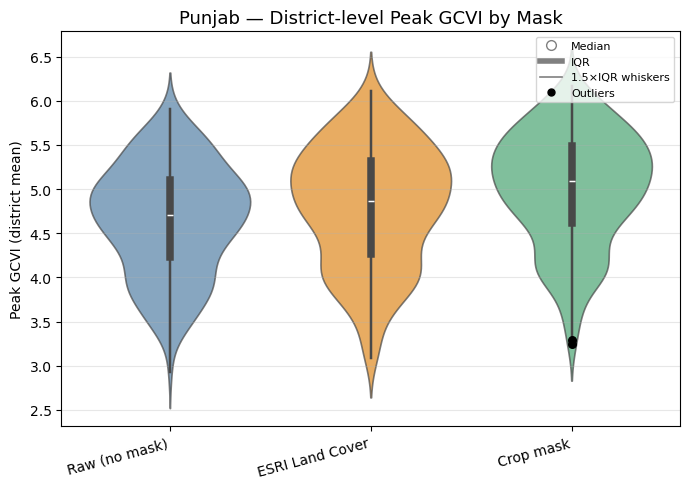

  Saved outputs/violin_punjab.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=10, rotation=15, ha='right')


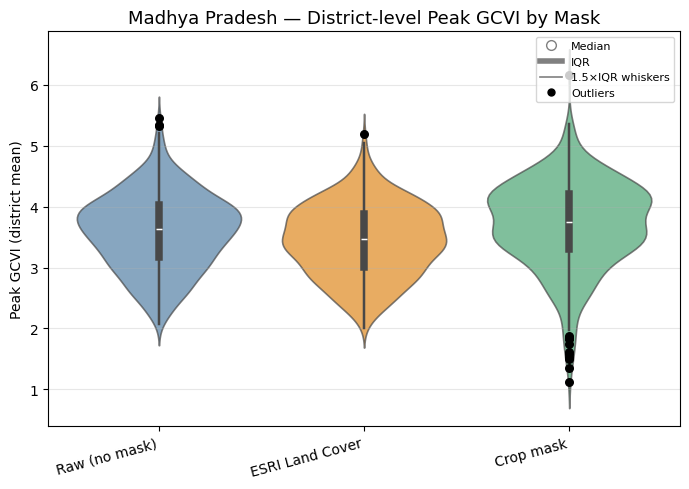

  Saved outputs/violin_mp.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=10, rotation=15, ha='right')


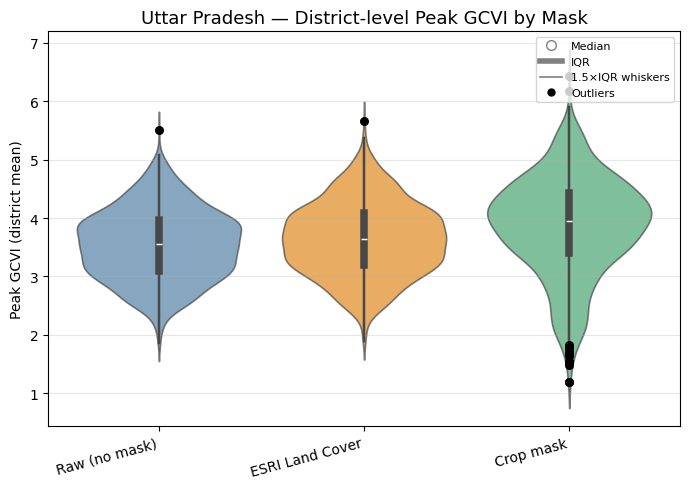

  Saved outputs/violin_up.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=10, rotation=15, ha='right')


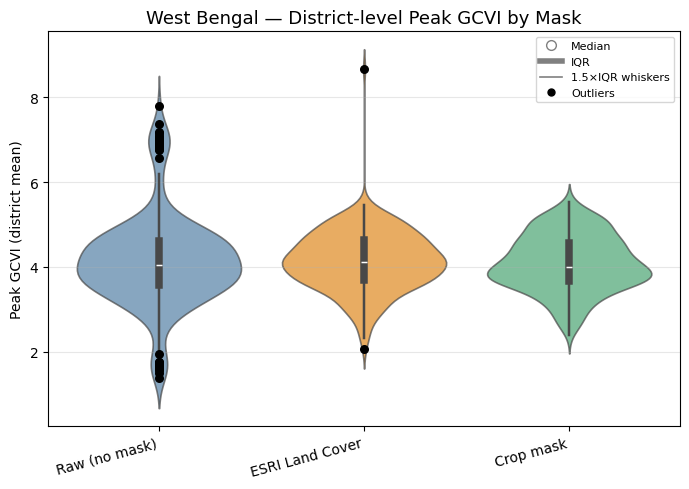

  Saved outputs/violin_wb.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=10, rotation=15, ha='right')


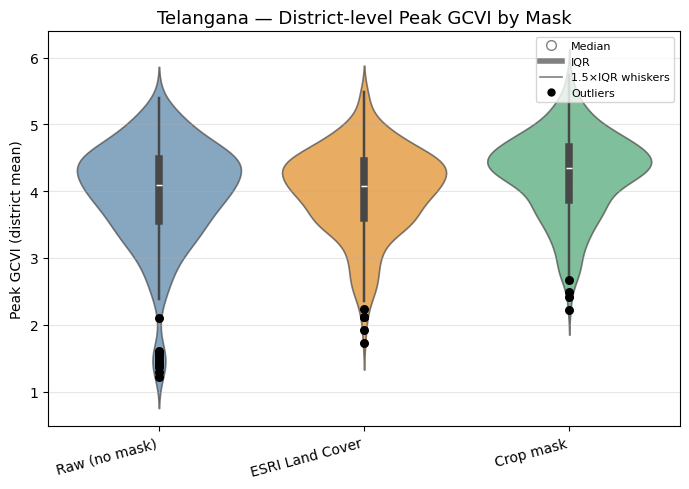

  Saved outputs/violin_telangana.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=10, rotation=15, ha='right')


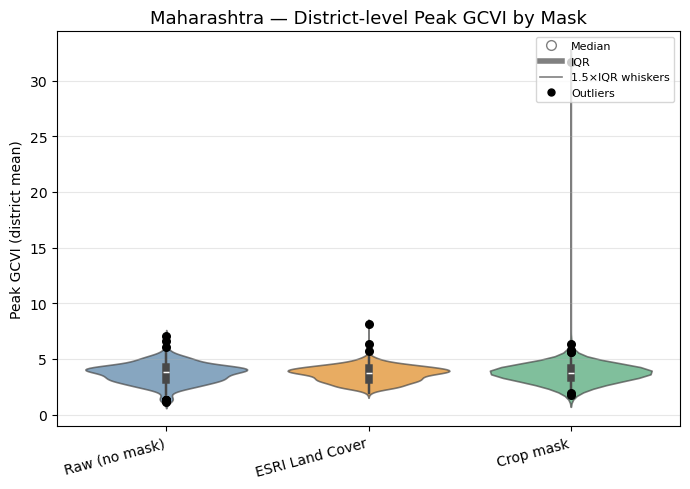

  Saved outputs/violin_maharashtra.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=10, rotation=15, ha='right')


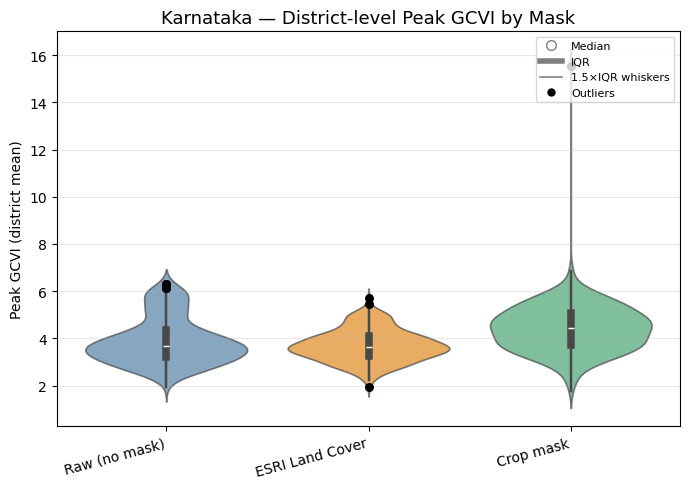

  Saved outputs/violin_karnataka.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=10, rotation=15, ha='right')


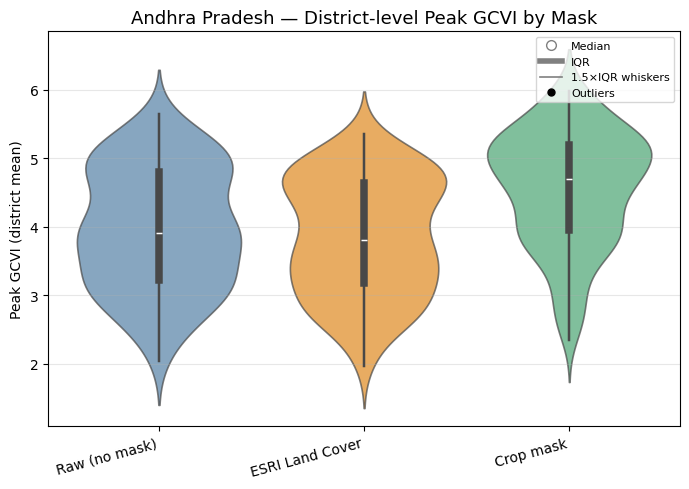

  Saved outputs/violin_andhra_pradesh.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=10, rotation=15, ha='right')


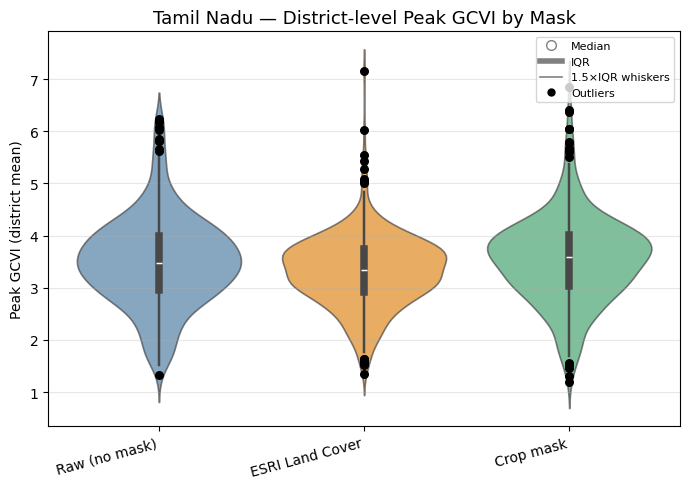

  Saved outputs/violin_tamil_nadu.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=10, rotation=15, ha='right')


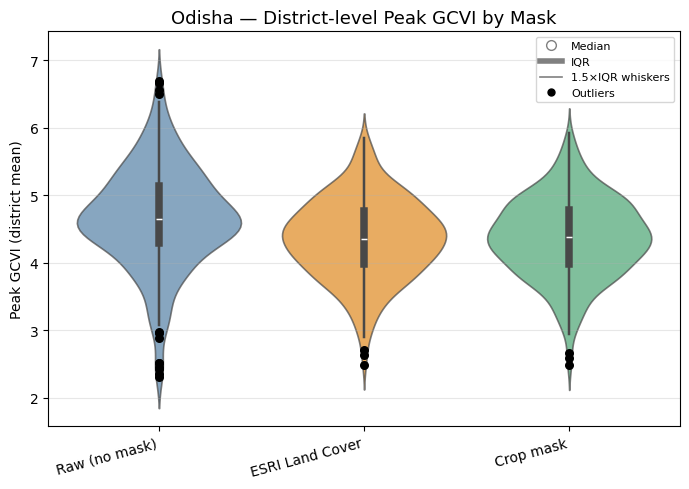

/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=10, rotation=15, ha='right')


  Saved outputs/violin_odisha.png


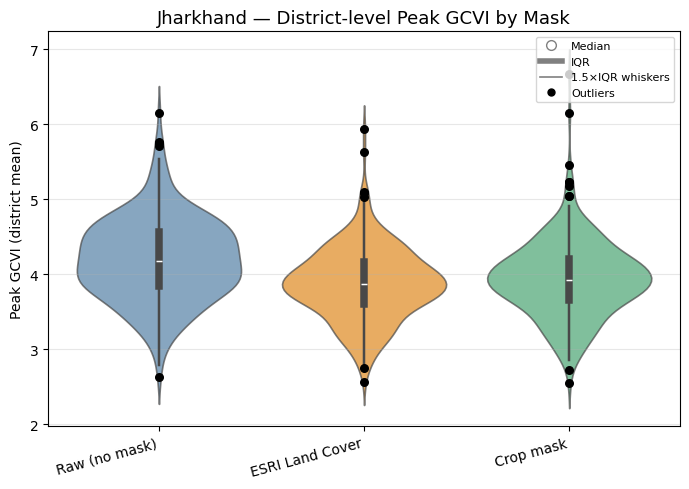

  Saved outputs/violin_jharkhand.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=10, rotation=15, ha='right')


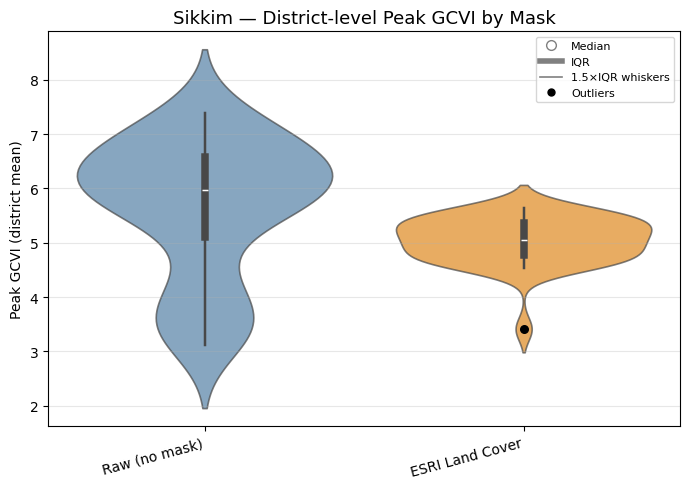

  Saved outputs/violin_sikkim.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=10, rotation=15, ha='right')


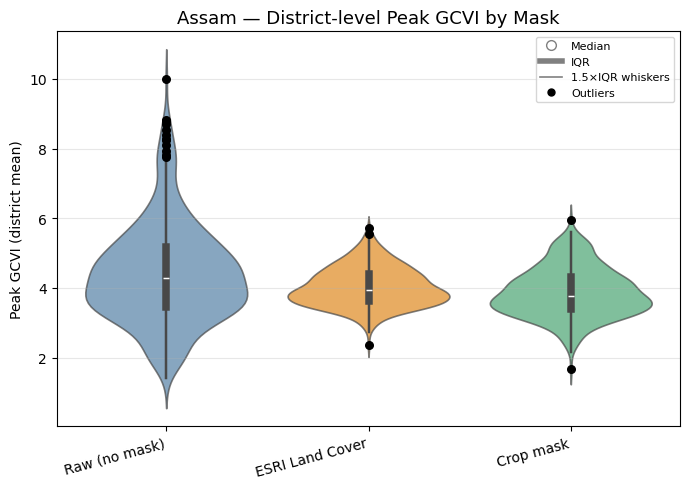

  Saved outputs/violin_assam.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=10, rotation=15, ha='right')


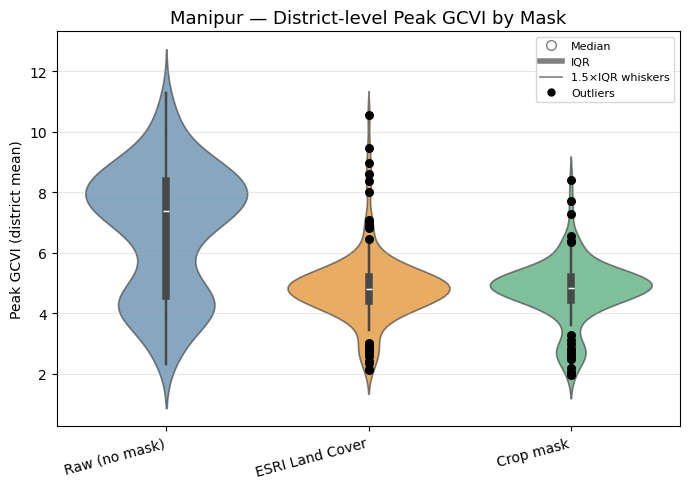

  Saved outputs/violin_manipur.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=10, rotation=15, ha='right')


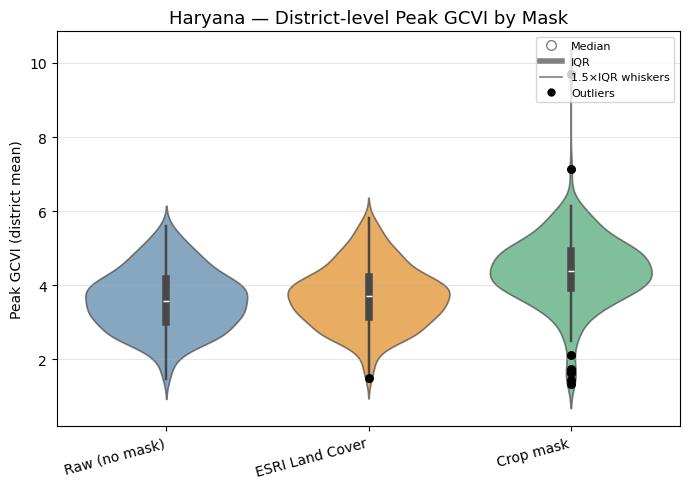

  Saved outputs/violin_haryana.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/4110069435.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=10, rotation=15, ha='right')


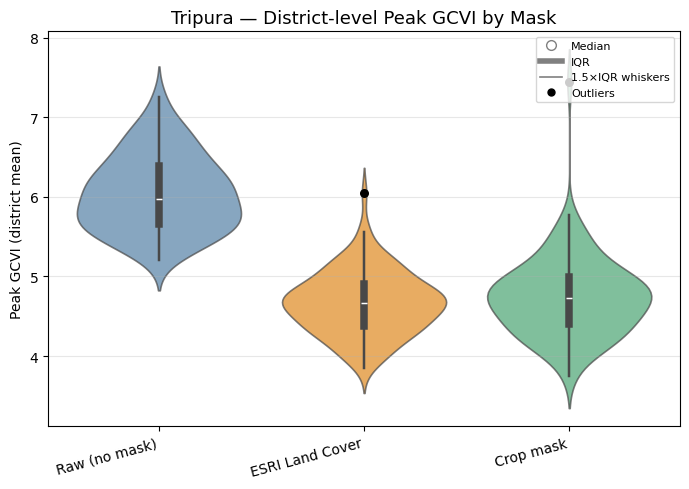

  Saved outputs/violin_tripura.png


In [7]:
from matplotlib.lines import Line2D

gcvi_long_rows = []
for region_key in REGIONS:
    for mask in REGION_MASKS[region_key]:
        gcvi_df = extract_gcvi(region_key, mask)
        gcvi_df = gcvi_df[gcvi_df['gcvi_mean'] > 0]
        gcvi_df['region'] = region_key
        gcvi_df['mask']   = mask
        gcvi_long_rows.append(gcvi_df)

gcvi_long_df = pd.concat(gcvi_long_rows, ignore_index=True)
gcvi_long_df['mask_label']   = gcvi_long_df['mask'].map(MASK_LABELS)
gcvi_long_df['region_label'] = gcvi_long_df['region'].map(REGION_LABELS)

legend_els = [
    Line2D([0], [0], color='white', marker='o', markerfacecolor='white',
           markeredgecolor='grey', markersize=7, label='Median'),
    Line2D([0], [0], color='grey', linewidth=4, label='IQR'),
    Line2D([0], [0], color='grey', linewidth=1.2, label='1.5×IQR whiskers'),
    Line2D([0], [0], color='black', marker='o', markersize=5,
           linestyle='None', label='Outliers'),
]

for region_key, region_label in REGION_LABELS.items():
    sub   = gcvi_long_df[gcvi_long_df['region'] == region_key]
    masks = REGION_MASKS[region_key]
    order   = [MASK_LABELS[m] for m in masks]
    palette = [MASK_COLORS[m] for m in masks]

    if sub.empty:
        print(f"Skipping violin for {region_key}: no GCVI data")
        continue

    fig, ax = plt.subplots(figsize=(7, 5))

    sns.violinplot(
        data=sub, x='mask_label', y='gcvi_mean',
        order=order, palette=palette,
        inner='box', linewidth=1.2, alpha=0.7, ax=ax
    )

    for i, mask in enumerate(masks):
        vals = sub[sub['mask_label'] == MASK_LABELS[mask]]['gcvi_mean']
        if vals.empty:
            continue
        q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
        iqr = q3 - q1
        outliers = vals[(vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)]
        ax.scatter([i] * len(outliers), outliers, color='black', s=30, zorder=5)

    ax.set_title(f'{region_label} — District-level Peak GCVI by Mask', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Peak GCVI (district mean)', fontsize=10)
    ax.set_xticklabels(order, fontsize=10, rotation=15, ha='right')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(handles=legend_els, fontsize=8, loc='upper right')

    plt.tight_layout()
    out_path = f'../../outputs/violin_{region_key}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved {out_path}")

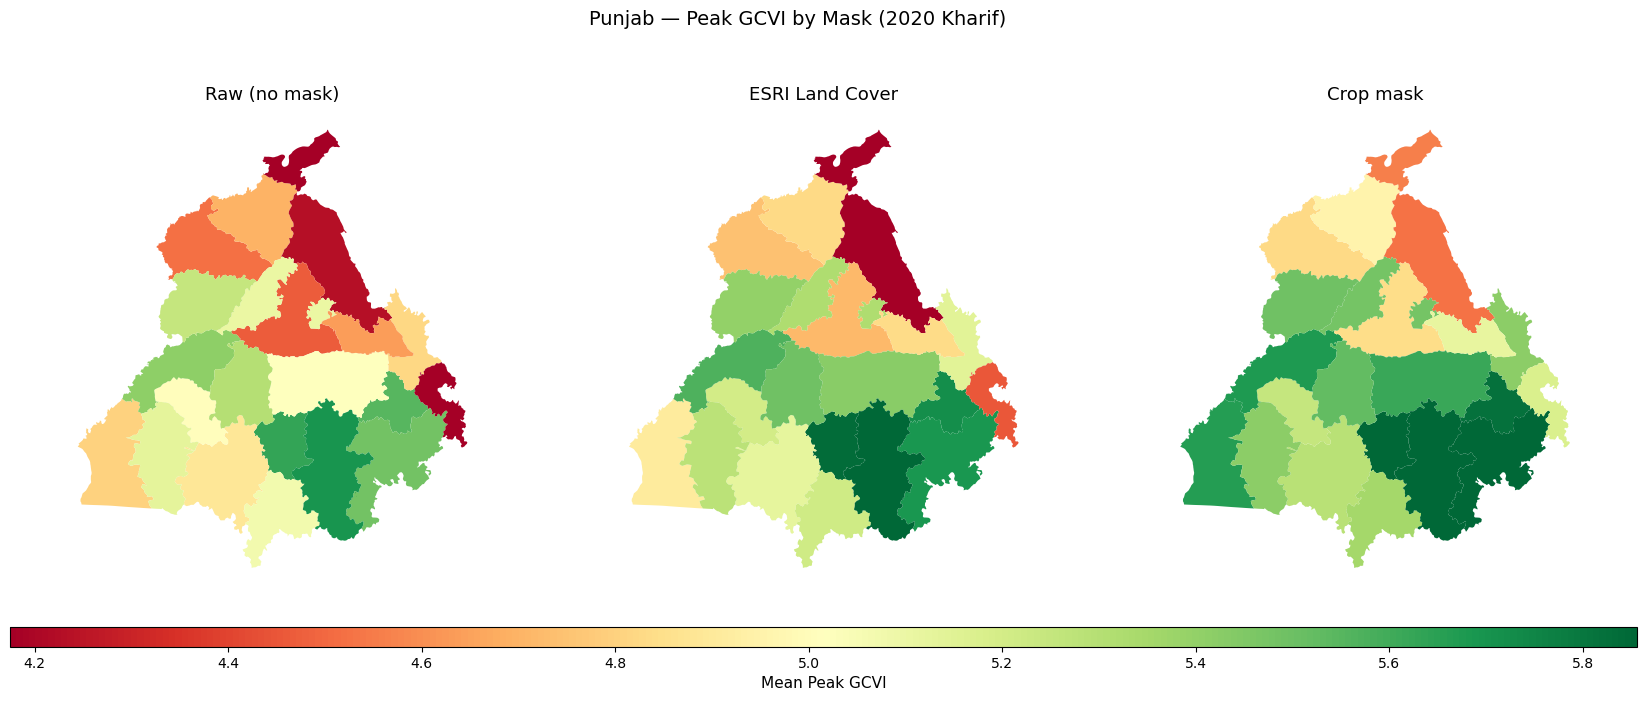

  Saved outputs/gcvi_map_punjab.png


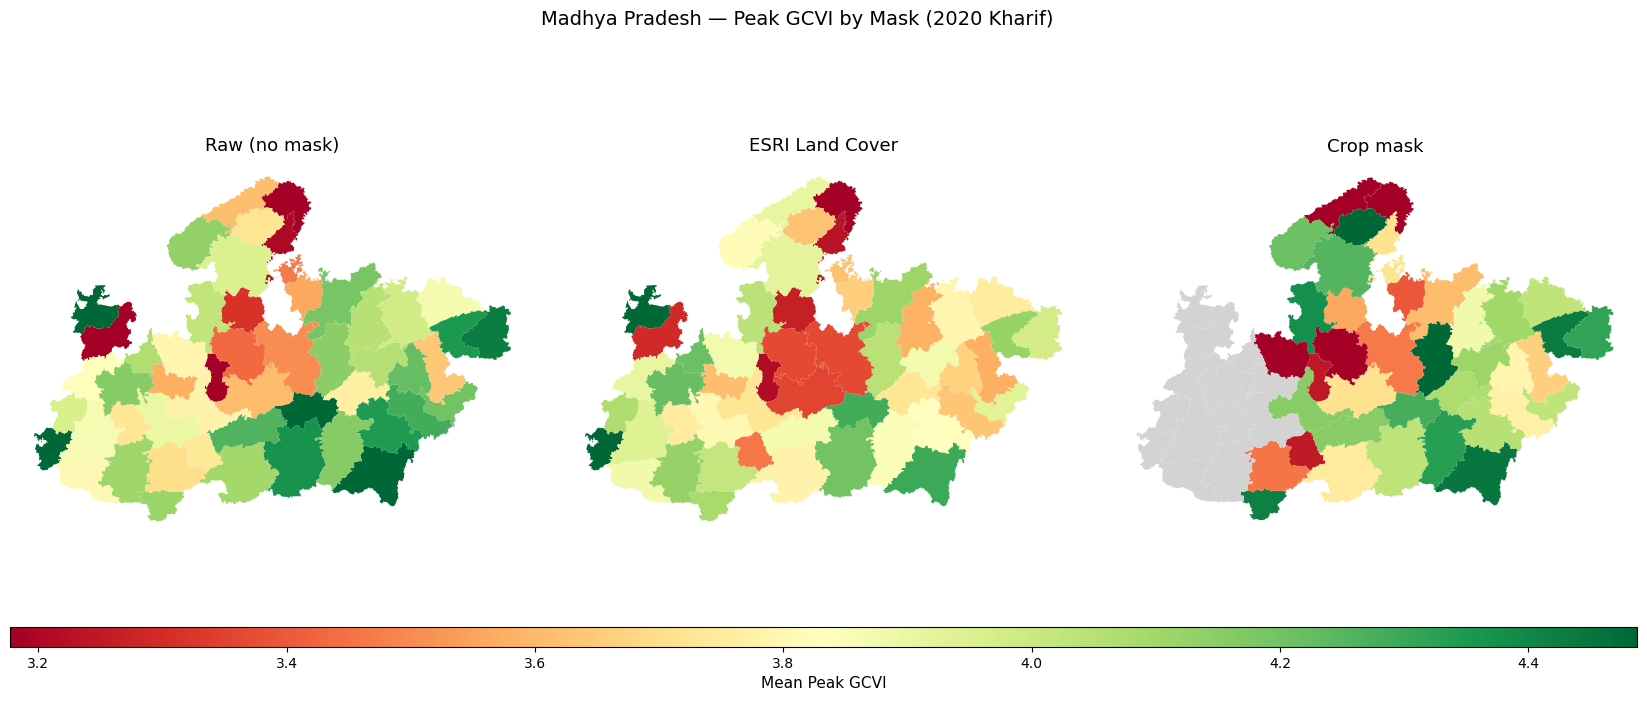

  Saved outputs/gcvi_map_mp.png


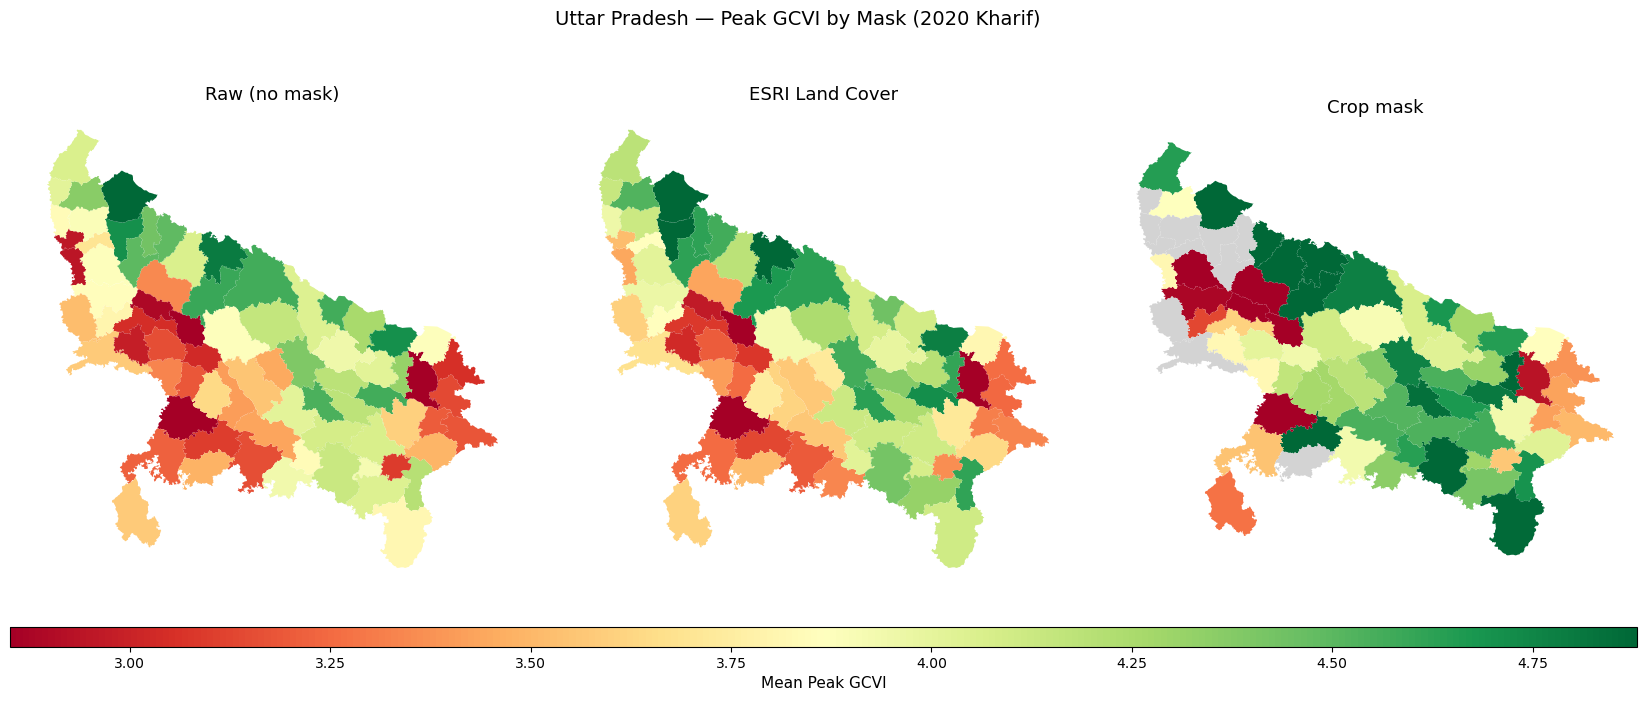

  Saved outputs/gcvi_map_up.png


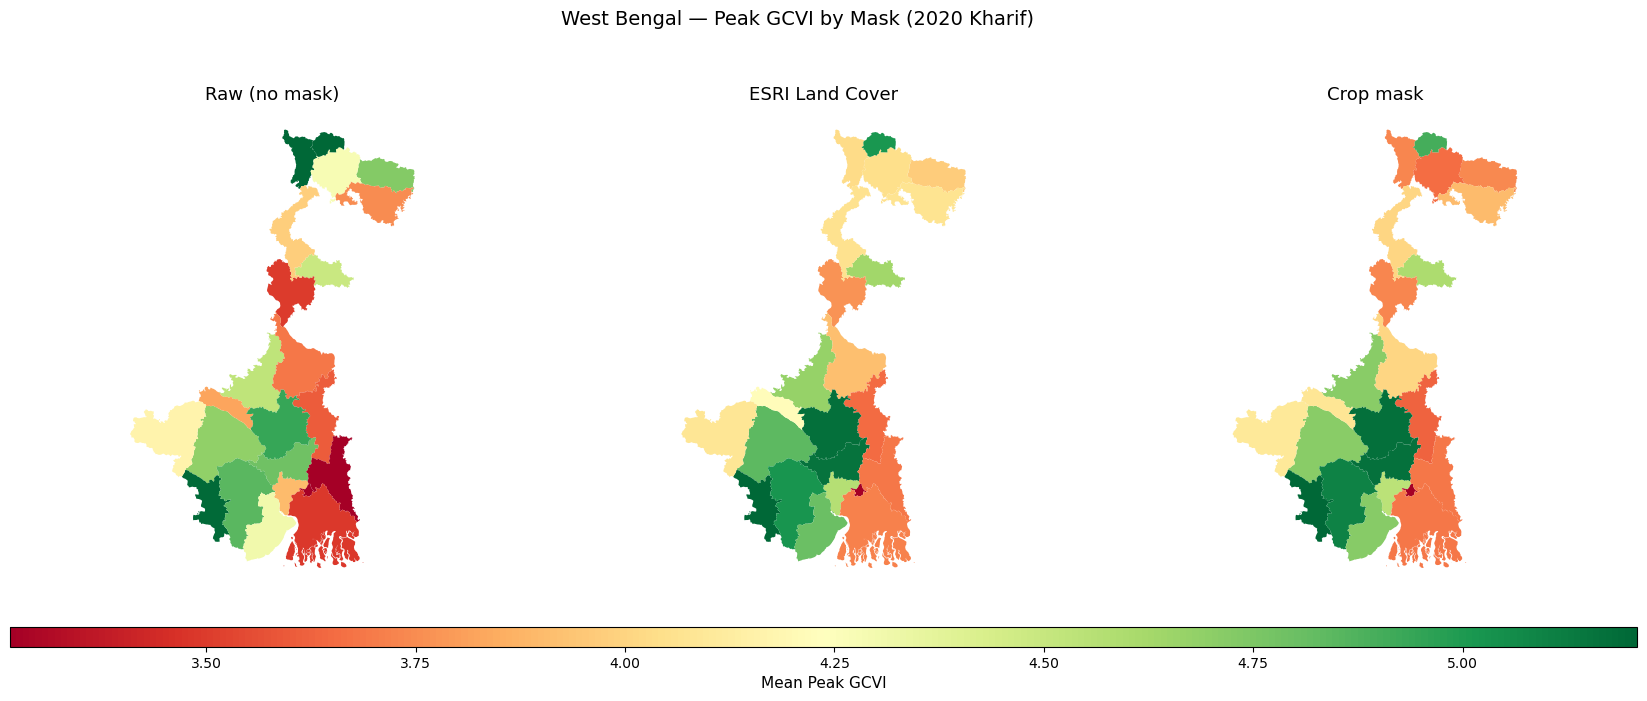

  Saved outputs/gcvi_map_wb.png


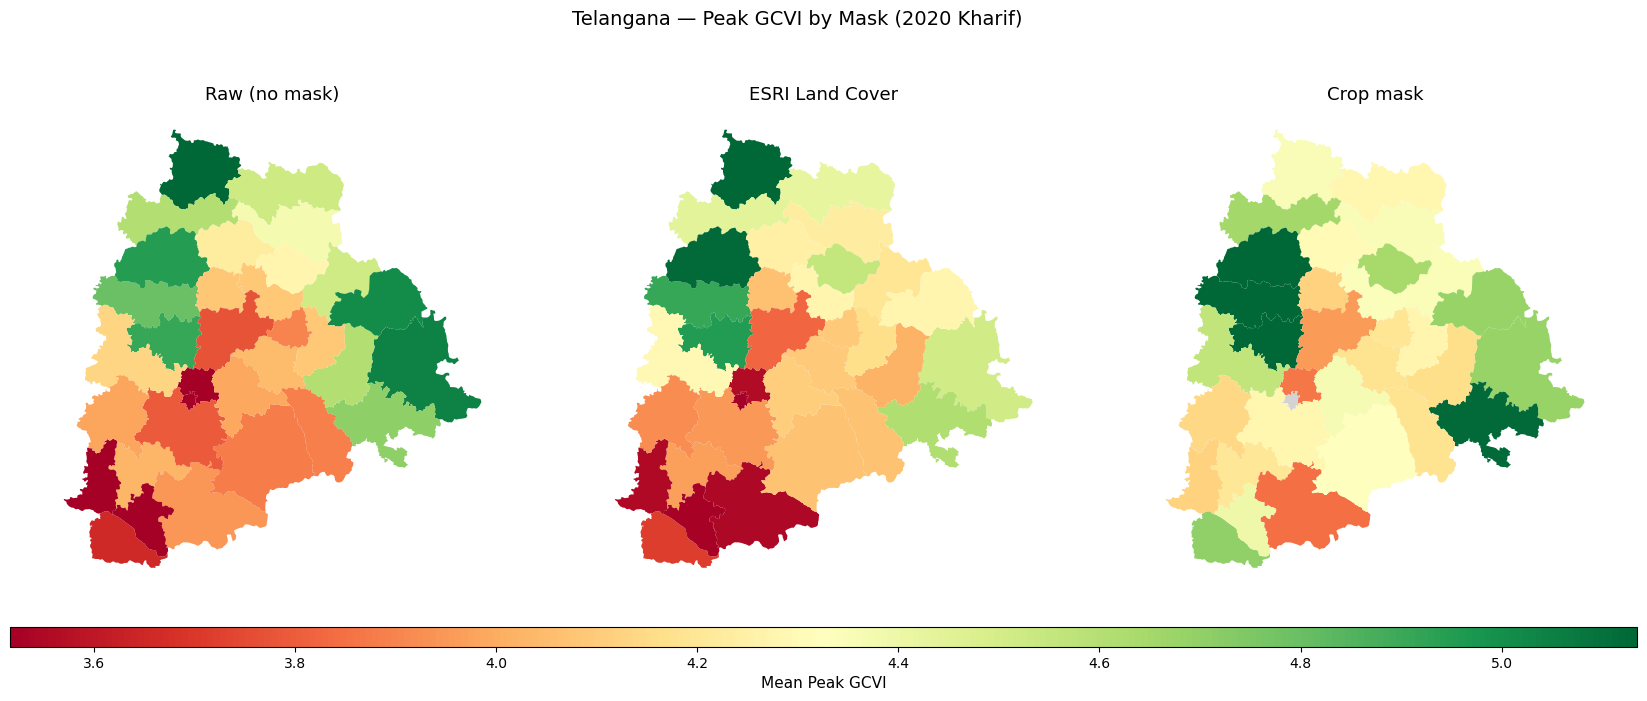

  Saved outputs/gcvi_map_telangana.png


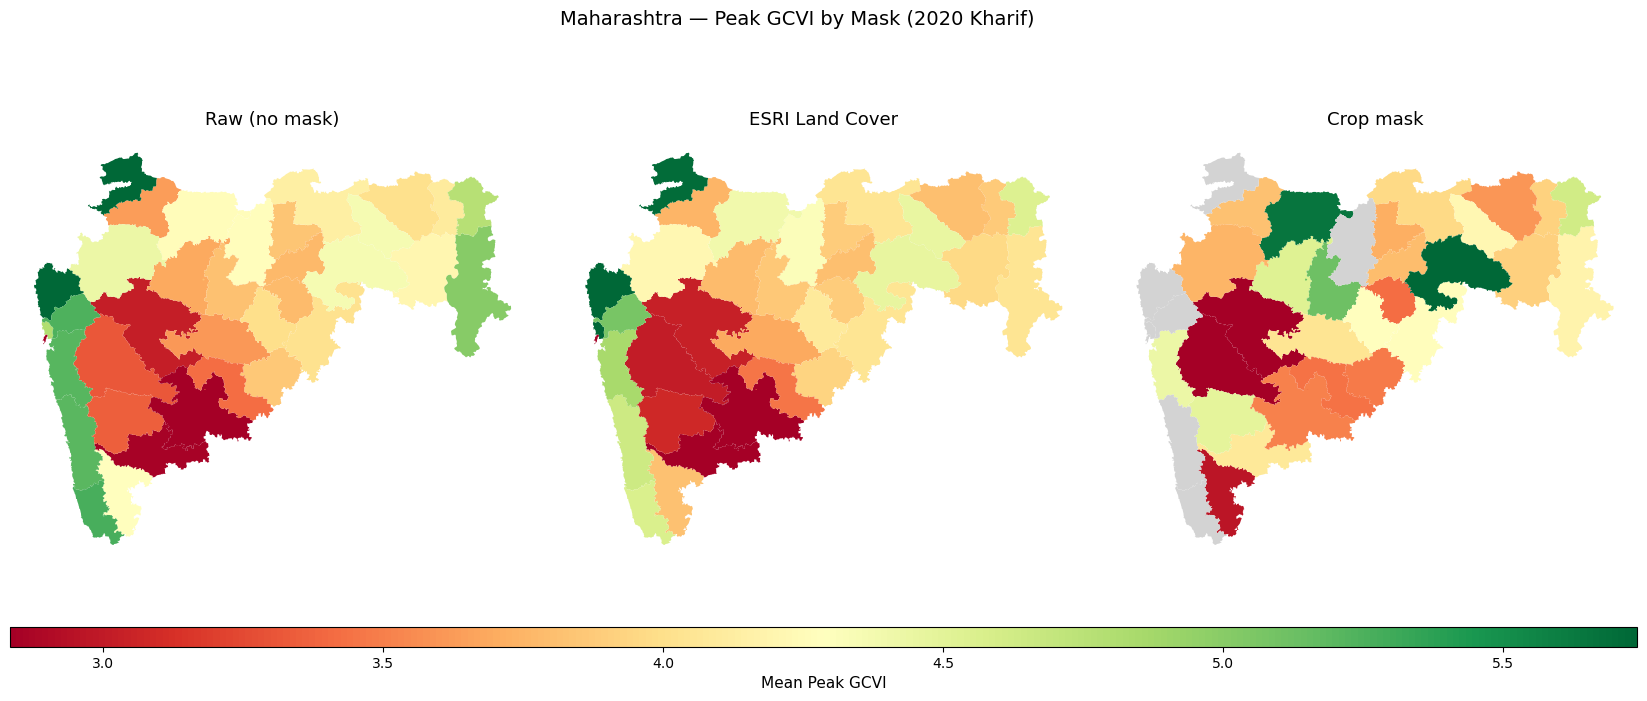

  Saved outputs/gcvi_map_maharashtra.png


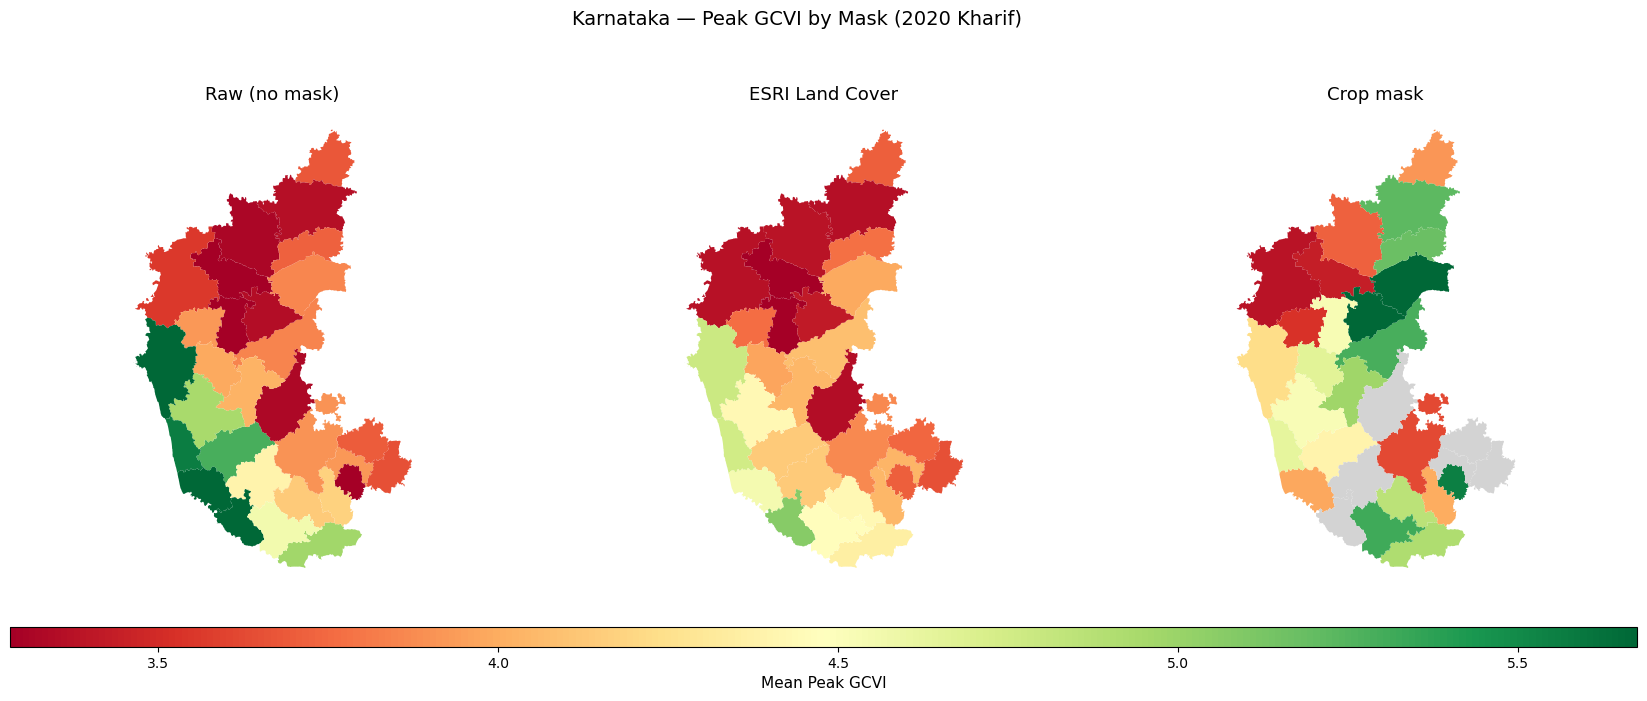

  Saved outputs/gcvi_map_karnataka.png


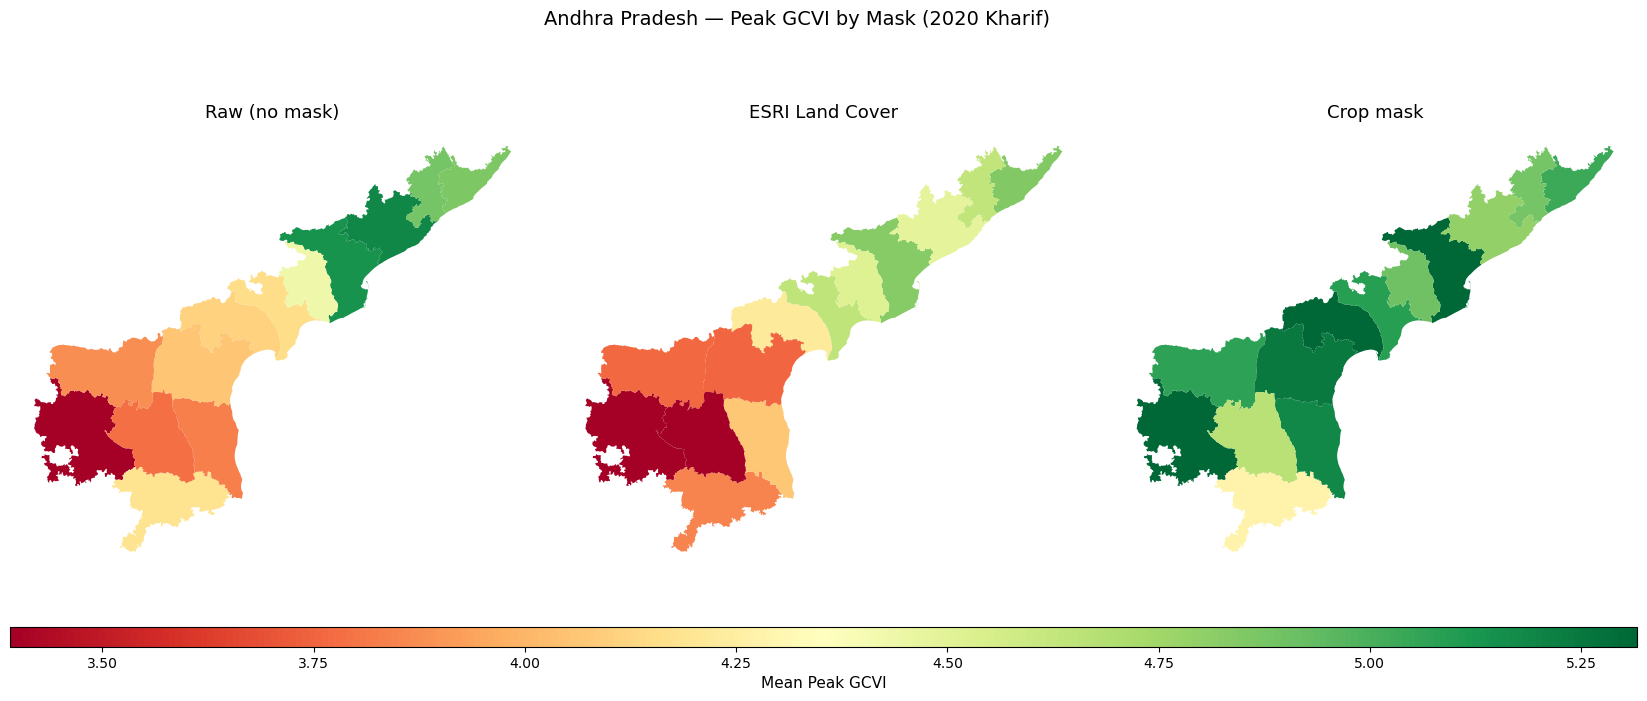

  Saved outputs/gcvi_map_andhra_pradesh.png


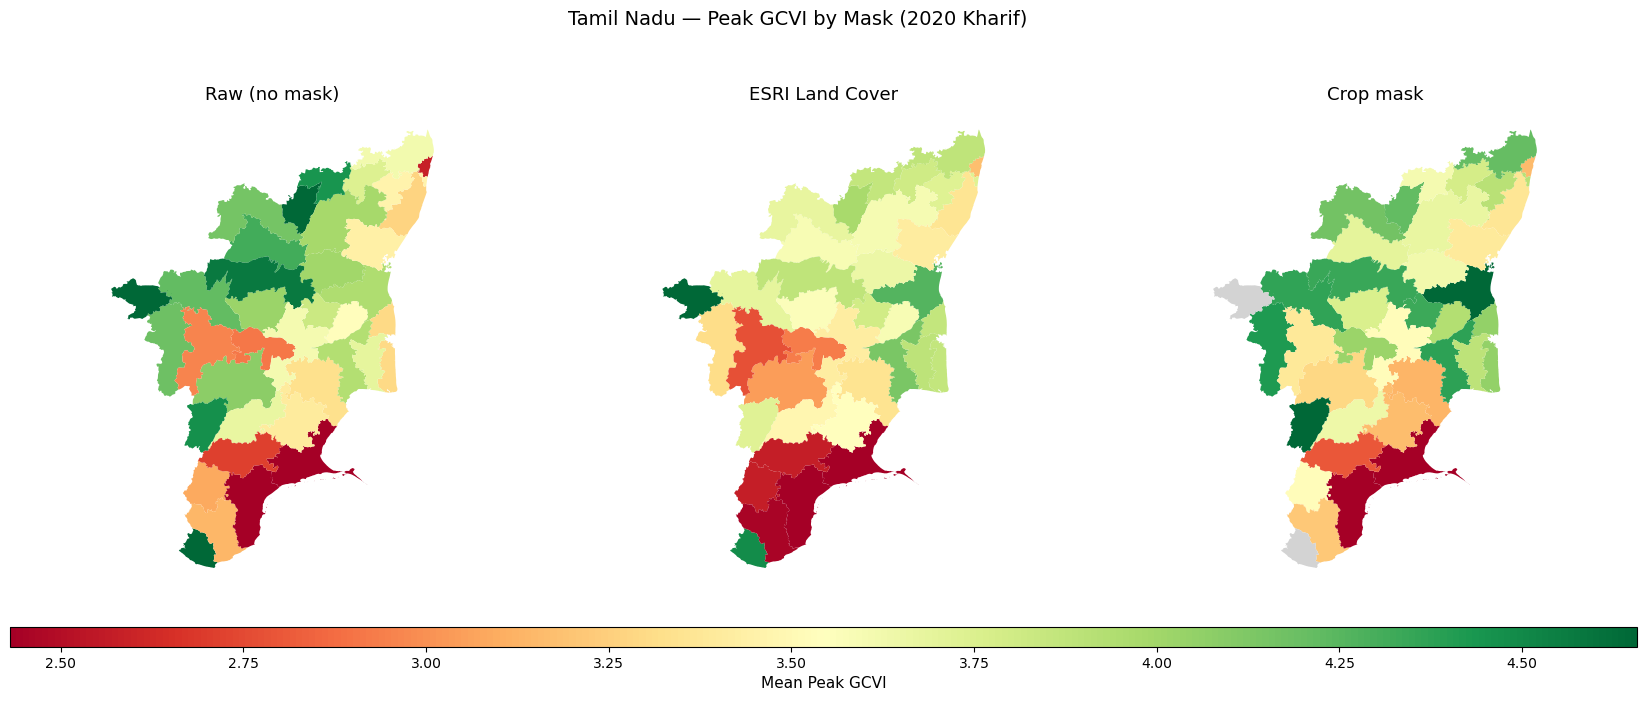

  Saved outputs/gcvi_map_tamil_nadu.png


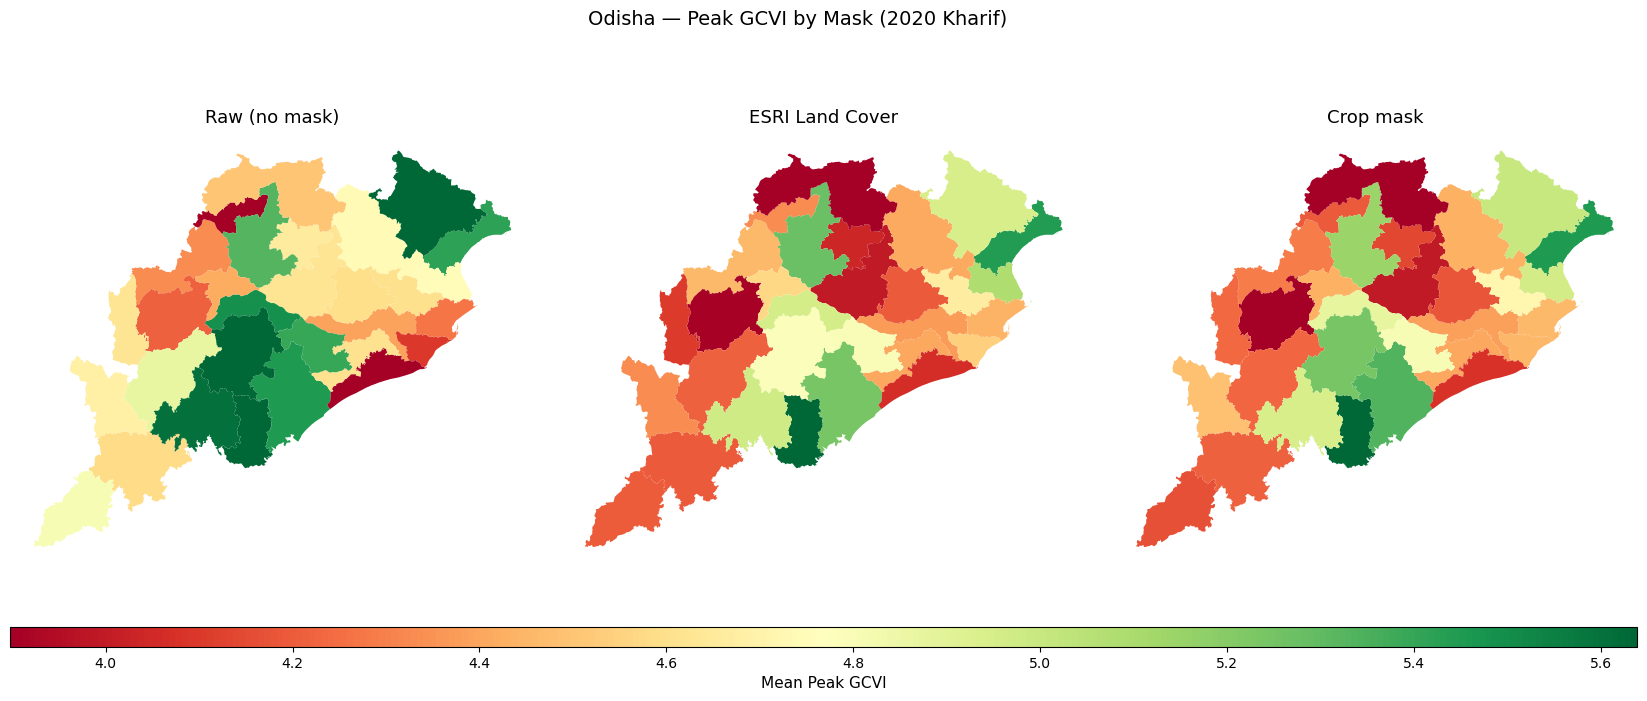

  Saved outputs/gcvi_map_odisha.png


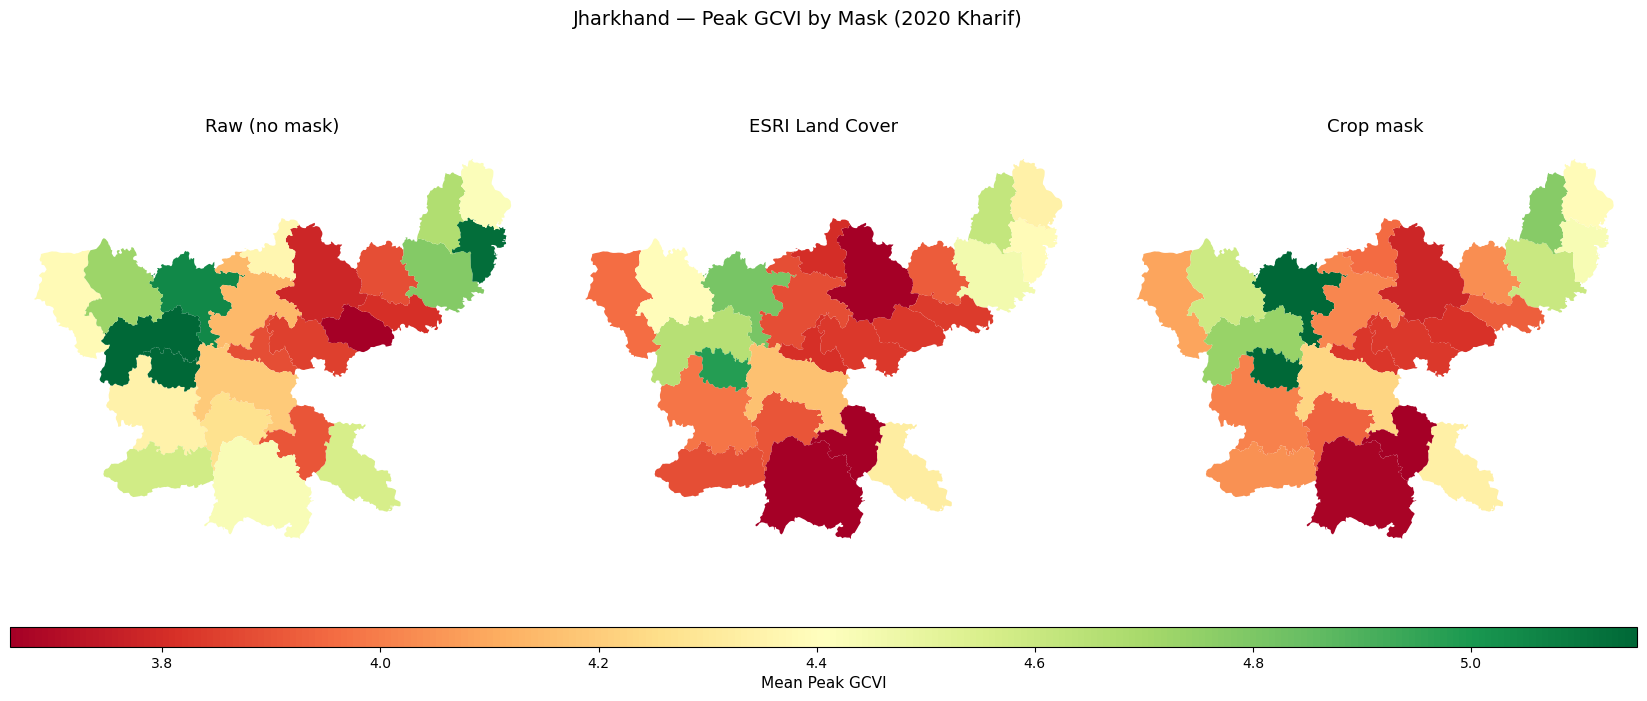

  Saved outputs/gcvi_map_jharkhand.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_27940/391512813.py:196: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gcvi_mean'] = df['gcvi_mean'].fillna(0)


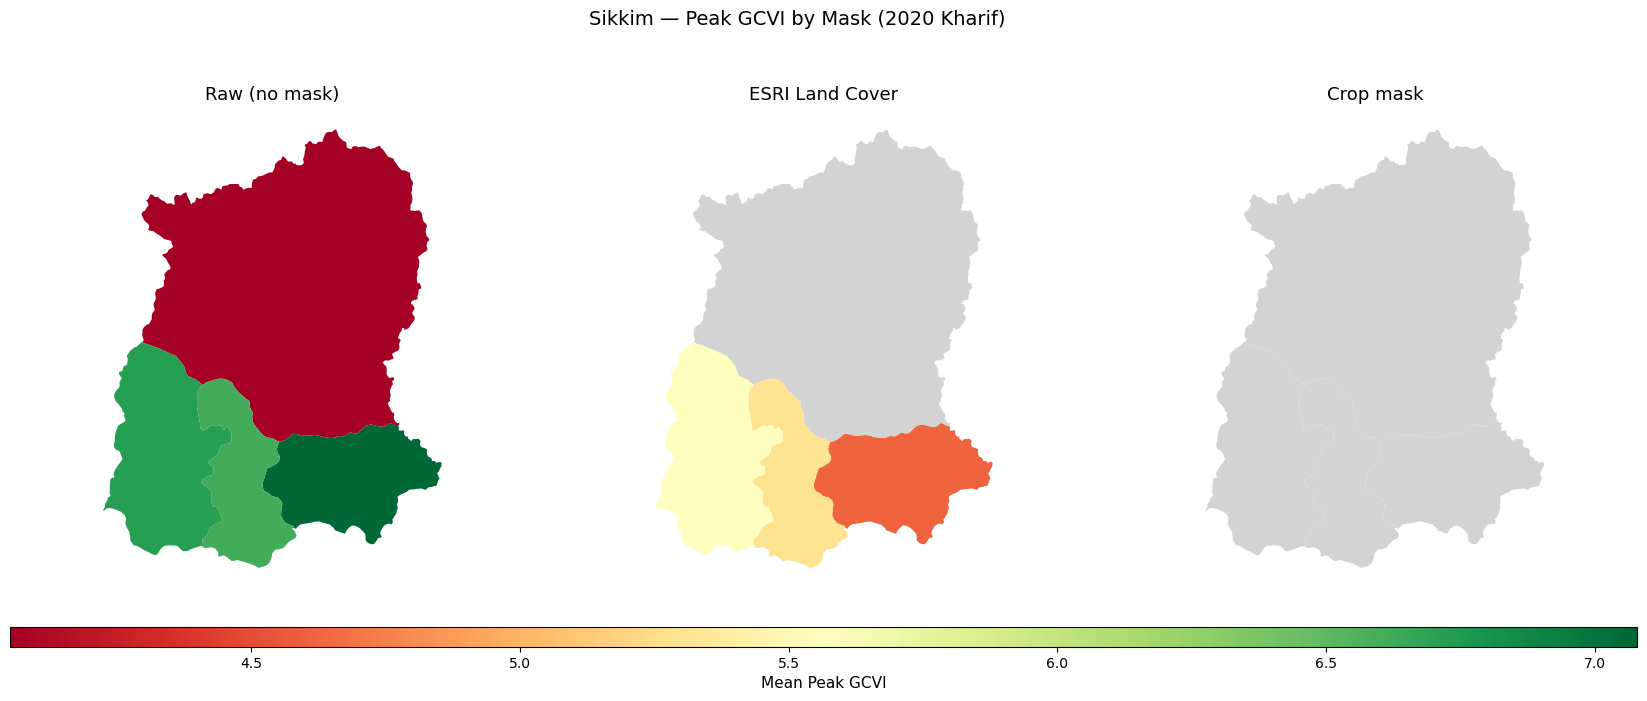

  Saved outputs/gcvi_map_sikkim.png


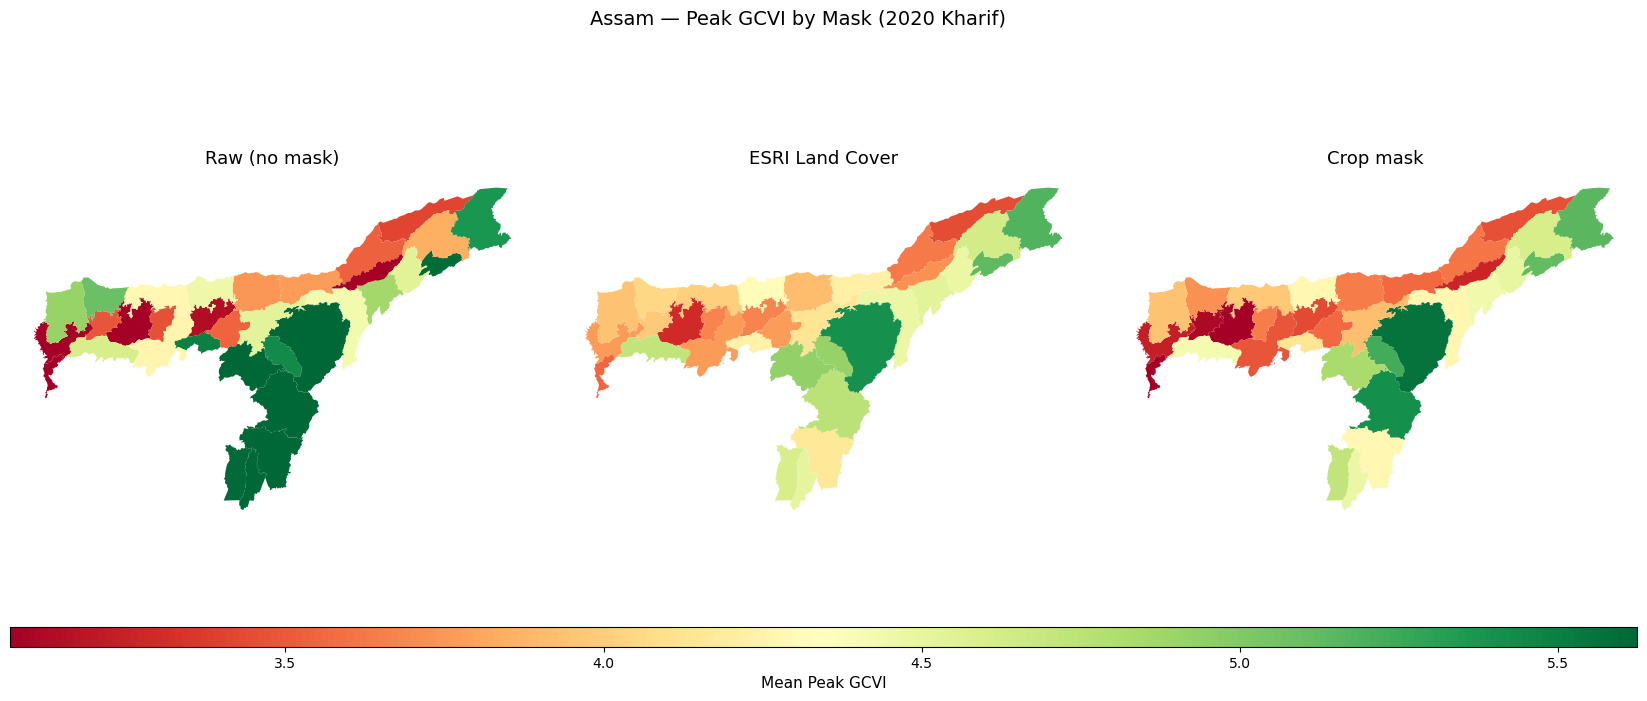

  Saved outputs/gcvi_map_assam.png


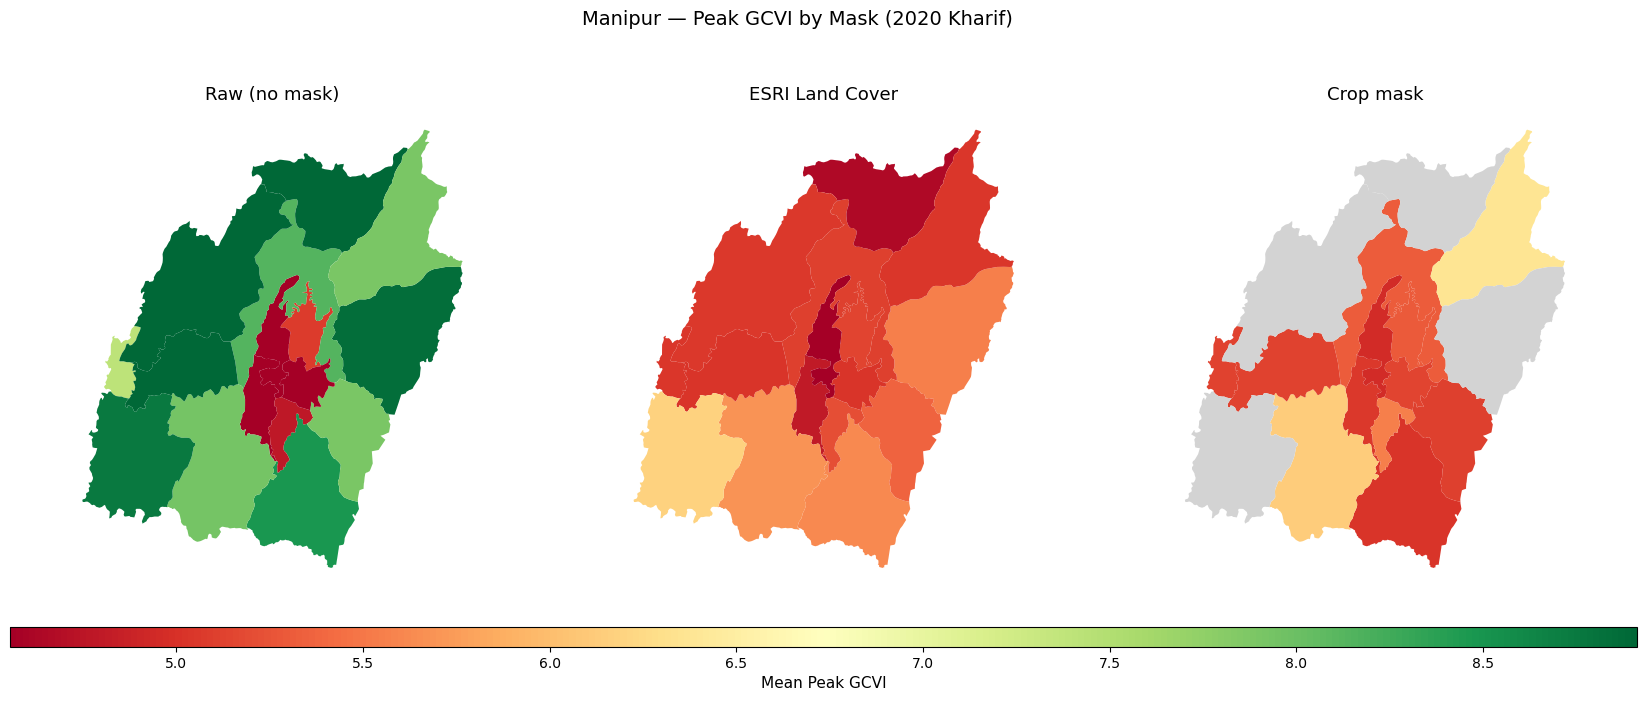

  Saved outputs/gcvi_map_manipur.png


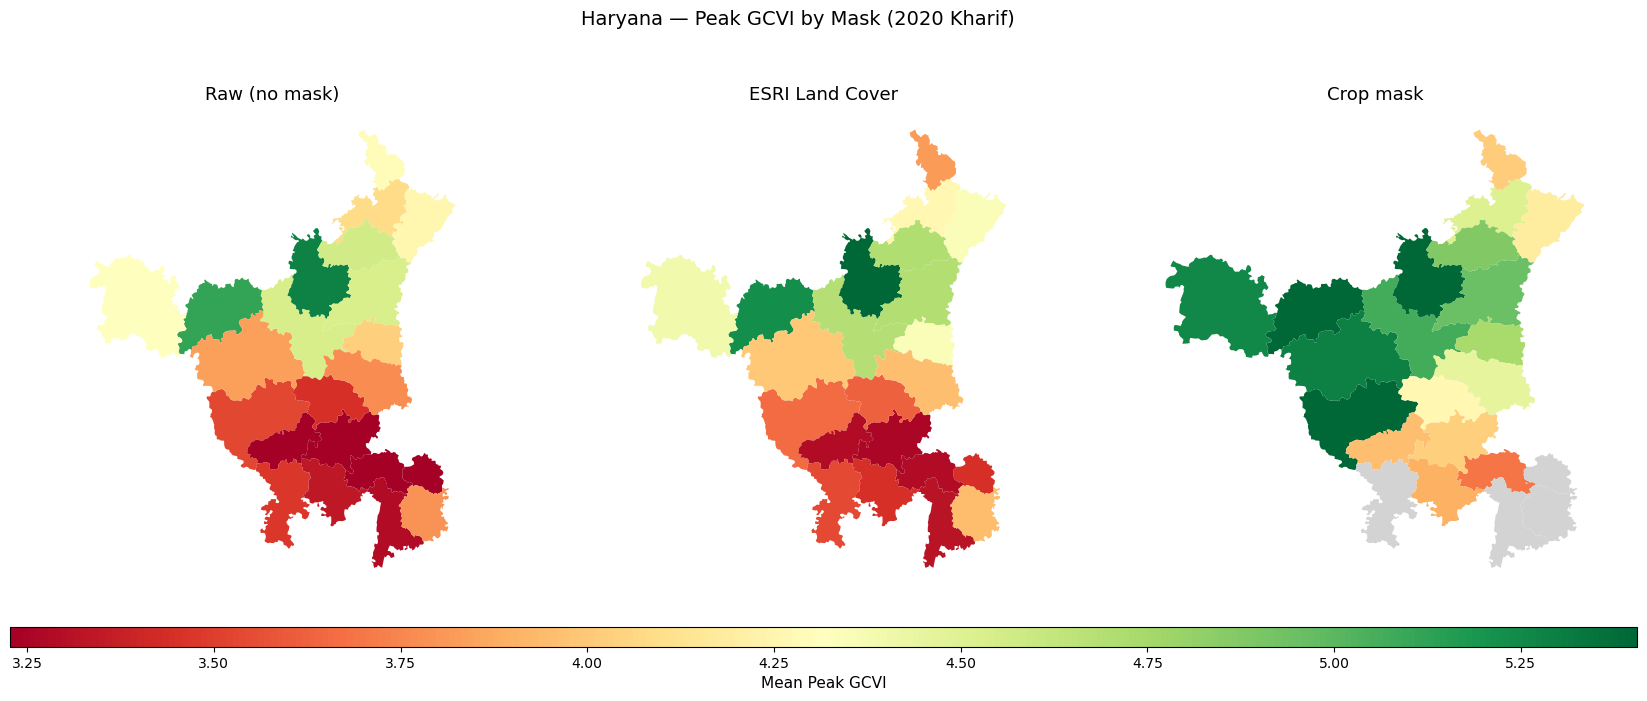

  Saved outputs/gcvi_map_haryana.png


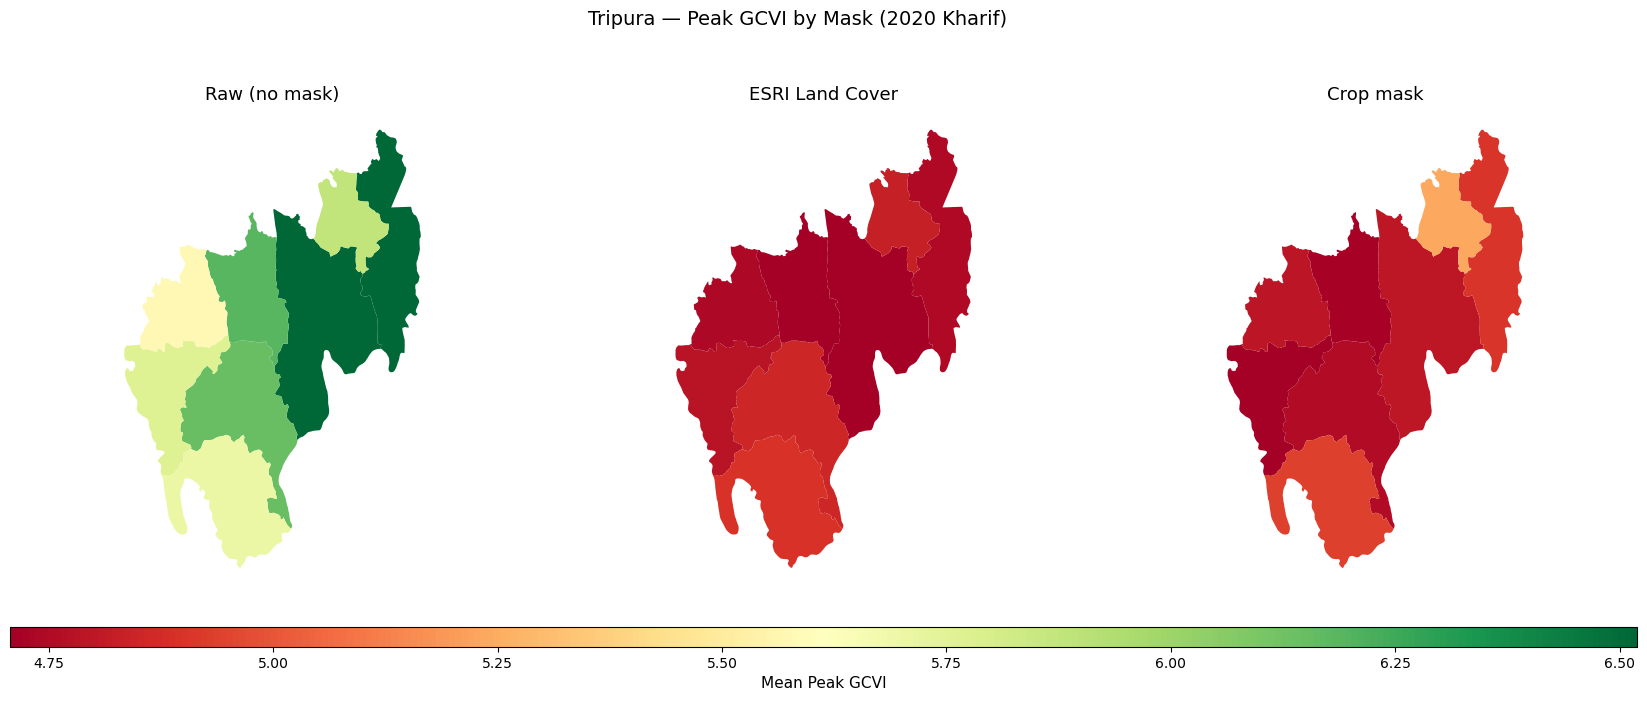

  Saved outputs/gcvi_map_tripura.png


In [8]:
import matplotlib.gridspec as gridspec

MAP_YEAR = 2020

for region_key, cfg in REGIONS.items():
    masks = REGION_MASKS[region_key]
    n_masks = len(masks)

    districts_gdf = gpd.read_file(cfg['shp']).to_crs('EPSG:4326')
    districts_gdf['gaul2_name'] = (districts_gdf['gaul2_name'].str.strip().str.title()
                                    .str.replace(r'\s+', ' ', regex=True))

    year_vals = {}
    for mask in masks:
        gcvi_df = extract_gcvi(region_key, mask)
        year_df = gcvi_df[gcvi_df['year'] == MAP_YEAR].copy()
        year_df = year_df[year_df['gcvi_mean'] > 0]
        year_vals[mask] = year_df

    all_vals = pd.concat(year_vals.values())['gcvi_mean'] if any(not v.empty for v in year_vals.values()) else pd.Series([0, 1])
    vmin = all_vals.quantile(0.05) if len(all_vals) else 0
    vmax = all_vals.quantile(0.95) if len(all_vals) else 1

    fig = plt.figure(figsize=(7 * n_masks, 7))
    gs  = gridspec.GridSpec(2, n_masks, figure=fig,
                            height_ratios=[10, 0.4], hspace=0.15, wspace=0.05)

    for col_idx, mask in enumerate(masks):
        ax = fig.add_subplot(gs[0, col_idx])
        merged_gdf = districts_gdf.merge(
            year_vals[mask][['district', 'gcvi_mean']],
            left_on='gaul2_name', right_on='district', how='left'
        )
        merged_gdf.plot(
            column='gcvi_mean', ax=ax, cmap='RdYlGn',
            vmin=vmin, vmax=vmax,
            missing_kwds={'color': 'lightgrey', 'label': 'No data'},
            legend=False
        )
        ax.set_title(MASK_LABELS[mask], fontsize=13)
        ax.axis('off')

    cbar_ax = fig.add_subplot(gs[1, :])
    sm = plt.cm.ScalarMappable(cmap='RdYlGn',
                                norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Mean Peak GCVI', fontsize=11)
    cbar.ax.tick_params(labelsize=10)

    fig.suptitle(f'{REGION_LABELS[region_key]} — Peak GCVI by Mask ({MAP_YEAR} Kharif)',
                 fontsize=14, y=1.02)

    out_path = f'../../outputs/gcvi_map_{region_key}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved {out_path}")